# Heart Stroke Prediciton
**Life cycle of Machine learning Project**

* Understanding the Problem Statement
* Data Collection
* Data Cleaning
* Exploratory data analysis
* Data Pre-Processing
* Model Training 
* Choose best model

## 1) Problem statement.

- In the proposed model, heart stroke prediction is performed on a dataset collected from Kaggle. The model predicts the chances a person will have stroke based on symptoms like age, gender, average glucose level, smoking status, body mass index, work type and residence type. 

## Install Libraries and packages

**Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.**

In [5]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
pip install numpy==1.24.4 --user

Could not fetch URL https://pypi.org/simple/numpy/: There was a problem confirming the ssl certificate: HTTPSConnectionPool(host='pypi.org', port=443): Max retries exceeded with url: /simple/numpy/ (Caused by SSLError("Can't connect to HTTPS URL because the SSL module is not available.")) - skipping
Could not fetch URL https://pypi.org/simple/pip/: There was a problem confirming the ssl certificate: HTTPSConnectionPool(host='pypi.org', port=443): Max retries exceeded with url: /simple/pip/ (Caused by SSLError("Can't connect to HTTPS URL because the SSL module is not available.")) - skipping
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement numpy==1.24.4 (from versions: none)
ERROR: No matching distribution found for numpy==1.24.4


In [7]:
pip install --upgrade matplotlib


Could not fetch URL https://pypi.org/simple/matplotlib/: There was a problem confirming the ssl certificate: HTTPSConnectionPool(host='pypi.org', port=443): Max retries exceeded with url: /simple/matplotlib/ (Caused by SSLError("Can't connect to HTTPS URL because the SSL module is not available.")) - skipping
Could not fetch URL https://pypi.org/simple/pip/: There was a problem confirming the ssl certificate: HTTPSConnectionPool(host='pypi.org', port=443): Max retries exceeded with url: /simple/pip/ (Caused by SSLError("Can't connect to HTTPS URL because the SSL module is not available.")) - skipping


In [8]:
pip install seaborn


Could not fetch URL https://pypi.org/simple/pip/: There was a problem confirming the ssl certificate: HTTPSConnectionPool(host='pypi.org', port=443): Max retries exceeded with url: /simple/pip/ (Caused by SSLError("Can't connect to HTTPS URL because the SSL module is not available.")) - skipping


### 2) Import Data

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
plt.rcParams['figure.figsize'] = (10, 5)

**Import the CSV Data as Pandas DataFrame**

In [12]:
data=pd.read_csv(r'C:\Users\Sneha\Documents\A\MSC 5th sem project\heart-stroke-prediction\heart-stroke-classifier\heart-stroke-classifier\Stroke-Risk-Prediction-using-Machine-Learning\dataset\healthcare-dataset-stroke-data.csv')
#load the dataset which is in csv format

**Show Top 5 Records**

In [14]:
data
#displaying the data

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


# Exploratory data analysis 
#data-preprocessing steps

**Shape of the dataset**

In [17]:
data.shape

(5110, 12)

**Summary of the dataset**

In [19]:
# Display summary statistics for a dataframe
data.describe()
#this summary is based out of all the numerical cols
#the mean age is 43.226
#the mean hypertension is categorical as well as the heart disease
#gluscose level mean is 106 and standard deviation is 45.283 and max is 271 
#the bmi mean is 28.89 which is on the higher side

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


### Statistical Inferences
- Median age of population is 43 years.
- 25% of the population is aged below 25
- Another 25% is aged above 60 and remaining in between these ages.
- Average glucose levels of the population is 106
- About 9.7% and 5.4% of population suffers from hypertension and heart disease respectively.
- People with higher BMI (BMI > 45) are less represented. This can affect our machine learning models significantly.

**Check Datatypes in the dataset**

In [22]:
data.info()
#in this dataset we see that except for 'bmi' one of the other parameters has any null values
#bmi has 201 null values which means there is no bmi data about some users in the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [23]:
data.isnull().sum()
#this command will show the sum of null values of each parameters, 
#if we remove the sum() function then it will show the dataset records so to get a sum count of it in total we give the sum() function

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

## 3. EXPLORING DATA

In [25]:
numeric_features = [feature for feature in data.columns if data[feature].dtype != 'O']
categorical_features = [feature for feature in data.columns if data[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 7 numerical features : ['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']

We have 5 categorical features : ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


### Feature Information
- Here we used the heart stroke dataset that is available in the kaggle website for our analysis. This dataset consists of total 12 attributes. The complete description of the attributes used in the proposed work is given below:
- **id** : This attribute means person’s id. It’s numerical data.
- **Age** : This attribute means a person’s age. It’s numerical data.
- **Gender** : This attribute means a person’s gender. It’s categorical data.
- **Hypertension** : This attribute means that this person is hypertensive or not. It’s numerical data.
- **work type** : This attribute represents the person work scenario. It’s categorical data.
- **residence type** : This attribute represents the person living scenario. It’s categorical data.
- **heart disease** : This attribute means whether this person has a heart disease person or not. It’s numerical data.
- **avg glucose level** : This attribute means what was the level of a person’s glucose condition. It’s numerical data.
- **Bmi** : This attribute means body mass index of a person. It’s numerical data.
- **ever married** : This attribute represents a person’s married status. It’s categorical data.
- **smoking Status** : This attribute means a person’s smoking condition. It’s categorical data.
- **Stroke** : This attribute means a person previously had a stroke or not.

In [27]:
for col in categorical_features:
    print(data[col].value_counts(normalize=True) * 100)
    print('---------------------------')

gender
Female    58.590998
Male      41.389432
Other      0.019569
Name: proportion, dtype: float64
---------------------------
ever_married
Yes    65.616438
No     34.383562
Name: proportion, dtype: float64
---------------------------
work_type
Private          57.240705
Self-employed    16.027397
children         13.444227
Govt_job         12.857143
Never_worked      0.430528
Name: proportion, dtype: float64
---------------------------
Residence_type
Urban    50.802348
Rural    49.197652
Name: proportion, dtype: float64
---------------------------
smoking_status
never smoked       37.025440
Unknown            30.215264
formerly smoked    17.318982
smokes             15.440313
Name: proportion, dtype: float64
---------------------------


## Univariate Analysis

* The term univariate analysis refers to the analysis of one variable prefix “uni” means “one.” The purpose of univariate analysis is to understand the distribution of values for a single variable.

### Numerical Features

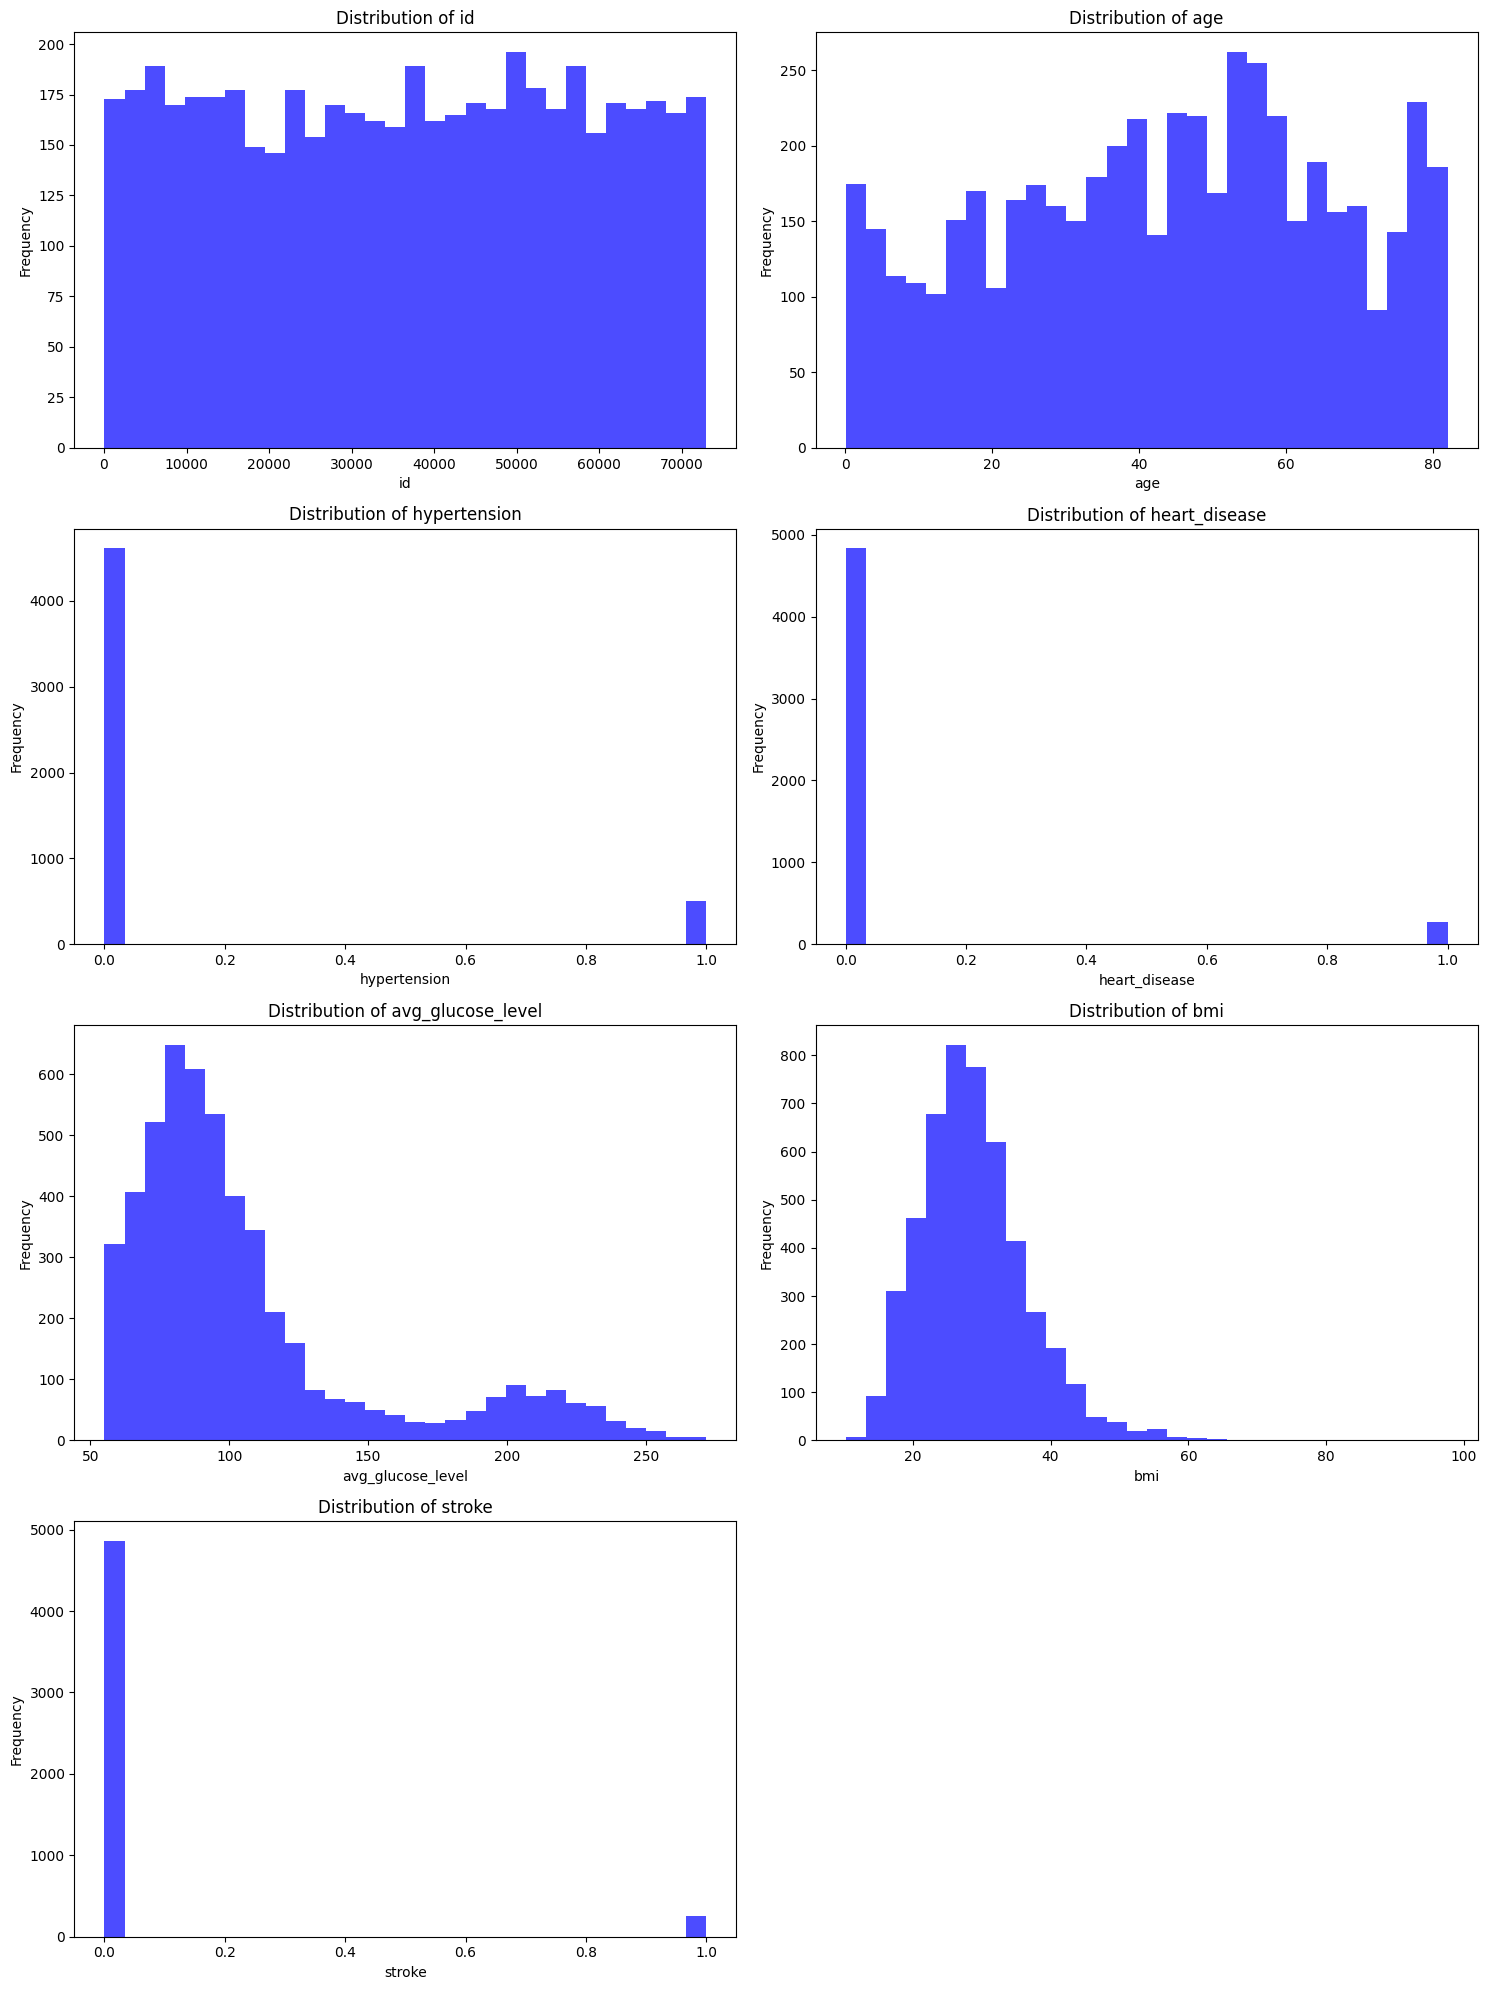

In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

# Sample DataFrame (replace with your actual data)
# df = pd.read_csv('your_data.csv')  # Load your dataset

# Identify numeric features
numeric_features = data.select_dtypes(include=[np.number]).columns.tolist()

# Dynamically calculate rows and columns for subplots
n_features = len(numeric_features)
n_cols = 2  # Number of columns
n_rows = math.ceil(n_features / n_cols)  # Dynamically calculate rows based on the number of features

plt.figure(figsize=(15, 5 * n_rows))  # Adjust height based on the number of rows

for i in range(n_features):
    plt.subplot(n_rows, n_cols, i + 1)

    # Clean the data by dropping NaN and infinite values
    data_to_plot = data[numeric_features[i]].dropna()
    data_to_plot = data_to_plot[~data_to_plot.isin([np.inf, -np.inf])]

    # Check if there's enough data to plot
    if len(data_to_plot) > 0:
        plt.hist(data_to_plot, bins=30, color='blue', alpha=0.7)
        plt.xlabel(numeric_features[i])
        plt.ylabel('Frequency')
        plt.title(f'Distribution of {numeric_features[i]}')
    else:
        plt.text(0.5, 0.5, 'No valid data', horizontalalignment='center', verticalalignment='center')

# Automatically adjust subplot parameters for a neat layout
plt.tight_layout()
plt.show()

**Report**
- `age`, `bmi`,`avg_glucose_level` are the only continuous features.
- `id` is a primary key which is of no importance.
- `hypertension`, `heart_disease`, `stroke` are Categorical features but they are encoded.

### Categorical Features

C:\Users\Sneha\AppData\Local\Temp\ipykernel_21496\1147922044.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[categorical_features[i]], palette='viridis')
C:\Users\Sneha\AppData\Local\Temp\ipykernel_21496\1147922044.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[categorical_features[i]], palette='viridis')
C:\Users\Sneha\AppData\Local\Temp\ipykernel_21496\1147922044.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[categorical_features[i]], palette='viridis')
C:\Users\Sneha\AppData\Local\Temp\ipykernel

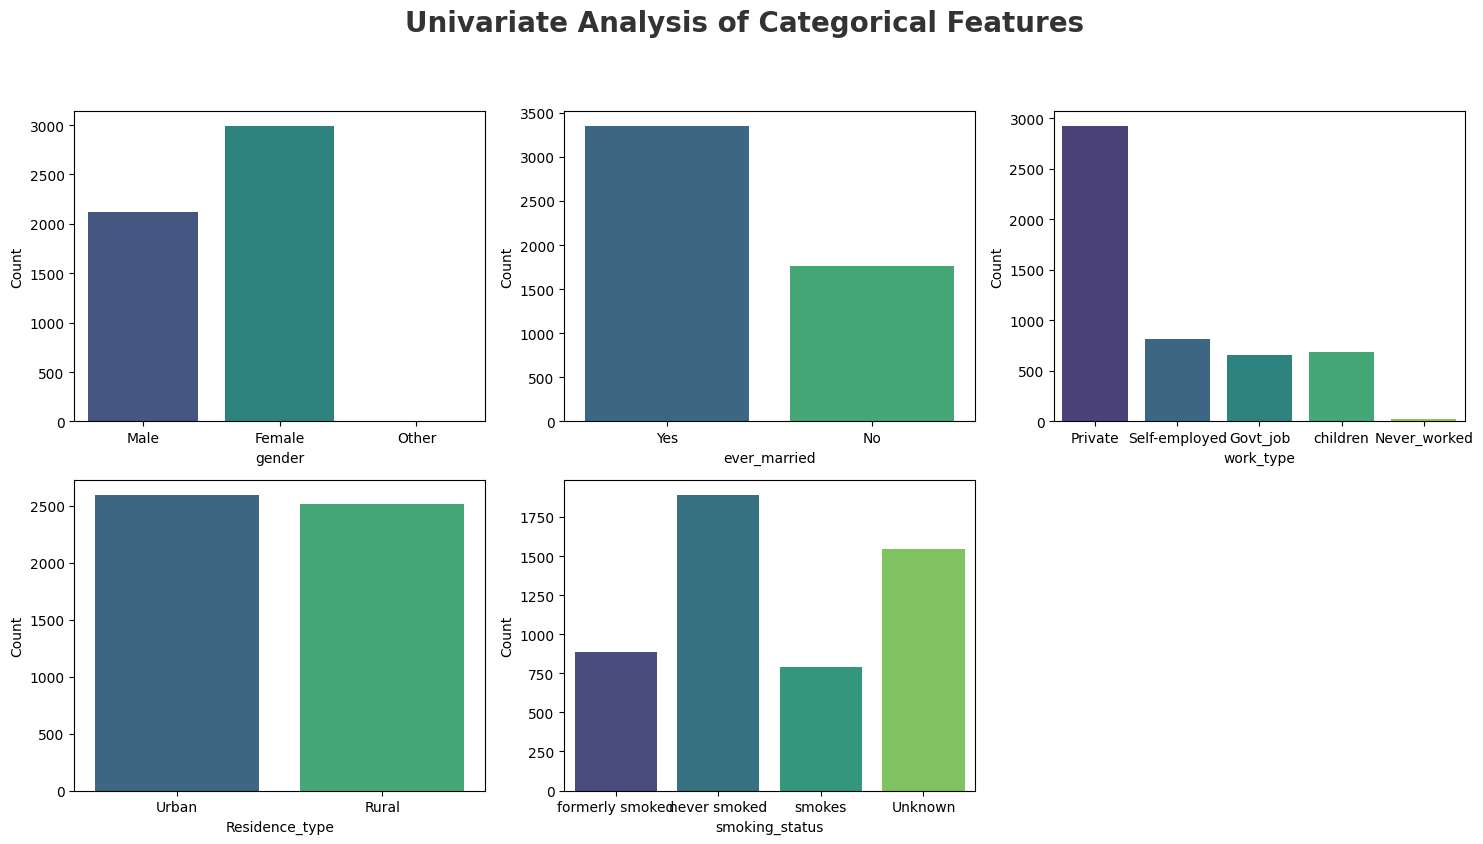

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'categorical_features' contains the column names for categorical data
# Check if categorical_features is not empty
if len(categorical_features) == 0:
    print("No categorical features to plot!")
else:
    n_features = len(categorical_features)
    n_cols = 3  # Number of columns in the subplot grid
    n_rows = (n_features + n_cols - 1) // n_cols  # Calculate rows needed

    plt.figure(figsize=(15, 8))
    plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.05)

    for i in range(n_features):
        plt.subplot(n_rows, n_cols, i + 1)
        sns.countplot(x=data[categorical_features[i]], palette='viridis')
        plt.xlabel(categorical_features[i])
        plt.ylabel('Count')

    plt.tight_layout()
    plt.show()


- `Gender` has Others category which is around 2% of total Genders.
- `smoking` has Unknown category for whom the smoking status is not available.

## Multivariate Analysis
* Multivariate analysis is the analysis of more than one variable.

In [37]:
discrete_features=[feature for feature in numeric_features if (len(data[feature].unique())<=25 and len(data[feature].unique())>5)]

continuous_features=[feature for feature in numeric_features if len(data[feature].unique()) > 25]

encoded_categorical = [feature for feature in numeric_features if len(data[feature].unique()) <=5]

print('We have {} discrete features : {}'.format(len(discrete_features), discrete_features))
print('\nWe have {} continuous_features : {}'.format(len(continuous_features), continuous_features))
print('\nWe have {} encoded_categorical : {}'.format(len(encoded_categorical), encoded_categorical))

We have 0 discrete features : []

We have 4 continuous_features : ['id', 'age', 'avg_glucose_level', 'bmi']

We have 3 encoded_categorical : ['hypertension', 'heart_disease', 'stroke']


In [38]:
categorical_features = categorical_features + encoded_categorical
print(categorical_features)

['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'hypertension', 'heart_disease', 'stroke']


### Check Multicollinearity in Numerical features

In [40]:
    data[(list(data[continuous_features])[1:])].corr()

,age,avg_glucose_level,bmi
age,1.000000,0.238171,0.333398
avg_glucose_level,0.238171,1.000000,0.175502
bmi,0.333398,0.175502,1.000000


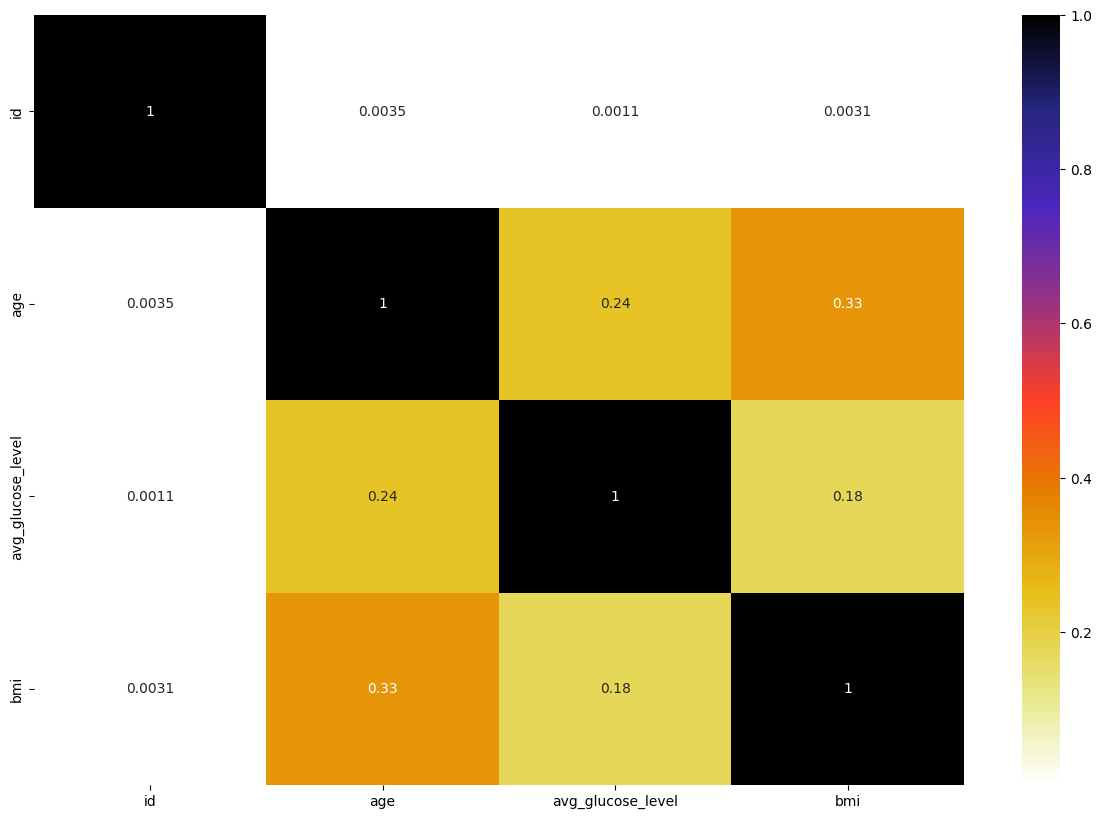

In [41]:
    plt.figure(figsize = (15,10))
    cont_features = continuous_features.copy()
    sns.heatmap(data[cont_features].corr(), cmap="CMRmap_r", annot=True)
    plt.show()

**Insight** 
* There is no multicollinearity present in the dataset since their is no correlation between the features.

### Check Multicollinearity for Categorical features

* **A chi-squared test (also chi-square or χ2 test) is a statistical hypothesis test that is valid to perform when the test statistic is chi-squared distributed under the null hypothesis, specifically Pearson's chi-squared test**

* **A chi-square statistic is one way to show a relationship between two categorical variables.**

* **Here we test correlation of Categorical columns with Target column i.e stroke**

**Null Hypothesis ($ H_0 $)**: The Feature is independent of target column (No-Correlation)

**Alternative Hypothesis ($ H_1 $)**: The Feature and Target column are not independent (Correlated)

In [46]:
from scipy.stats import chi2_contingency
chi2_test = []
for feature in categorical_features:
    if chi2_contingency(pd.crosstab(data['stroke'], data[feature]))[1] < 0.05:
        chi2_test.append('Reject Null Hypothesis')
    else:
        chi2_test.append('Fail to Reject Null Hypothesis')
result = pd.DataFrame(data=[categorical_features, chi2_test]).T
result.columns = ['Column', 'Hypothesis Result']
result

,Column,Hypothesis Result
0,gender,Fail to Reject Null Hypothesis
1,ever_married,Reject Null Hypothesis
2,work_type,Reject Null Hypothesis
3,Residence_type,Fail to Reject Null Hypothesis
4,smoking_status,Reject Null Hypothesis
5,hypertension,Reject Null Hypothesis
6,heart_disease,Reject Null Hypothesis
7,stroke,Reject Null Hypothesis


Let's deal with the gender column which has a category `other` with only one observation and check the hypothesis again

In [48]:
df1 = data.copy()
df1.gender = np.where(data.gender == 'Other', 'Female', data.gender)

In [49]:
chi2_contingency(pd.crosstab(df1['stroke'], df1['gender']))

Chi2ContingencyResult(statistic=0.34312923759376157, pvalue=0.5580285118426893, dof=1, expected_freq=array([[2849.05968689, 2011.94031311],
       [ 145.94031311,  103.05968689]]))

Even after the substitution the difference in not significant and we fail to reject the null hypothesis.

**Report**
- `Gender` and `Residence_type` are independent of the target columnn (Not-Correlated with target)

# Lets fill Null Values
#we should always handle the missimg values in the datset while always preparing the data
#we have 201 rows of missing values put of the total 5110rows in the dataset

In [53]:
data['bmi'].value_counts()
#lets explore the bmi
#lHS concludes the bmi status and the RHS defines the no.of people falling in the mentioned value of bmi index

bmi
28.7    41
28.4    38
26.7    37
27.6    37
26.1    37
        ..
48.7     1
49.2     1
51.0     1
49.4     1
14.9     1
Name: count, Length: 418, dtype: int64

In [54]:
data['bmi'].describe()
#this shows the complete descripted detail of the parameter bmi
#in which out of 4909rows on an average out of 4909 people records average  amount of people has 28.89 as their bmi
#

count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64

In [55]:
data['bmi'].fillna(data['bmi'].mean(),inplace=True)
#filling missing values using 'mean' with the average count, im gonna fill the remaining 201 rows of null values with the average mean count that is 28.89
#fillna means drop it or fill the null values
#inplace is means to inplace it permantely

C:\Users\Sneha\AppData\Local\Temp\ipykernel_21496\3567315385.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['bmi'].fillna(data['bmi'].mean(),inplace=True)


In [56]:
data['bmi'].describe()

count    5110.000000
mean       28.893237
std         7.698018
min        10.300000
25%        23.800000
50%        28.400000
75%        32.800000
max        97.600000
Name: bmi, dtype: float64

In [57]:
data.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

C:\Users\Sneha\AppData\Local\Temp\ipykernel_21496\2807304986.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='stroke', y=col,  palette=clr1, ax=ax[i,0])
C:\Users\Sneha\AppData\Local\Temp\ipykernel_21496\2807304986.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='stroke', y=col,  palette=clr1, ax=ax[i,0])
C:\Users\Sneha\AppData\Local\Temp\ipykernel_21496\2807304986.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='stroke', y=col,  palette=clr1, ax=ax[i,0])
C:\Users\Sneha\AppData\Local\Temp\ipy

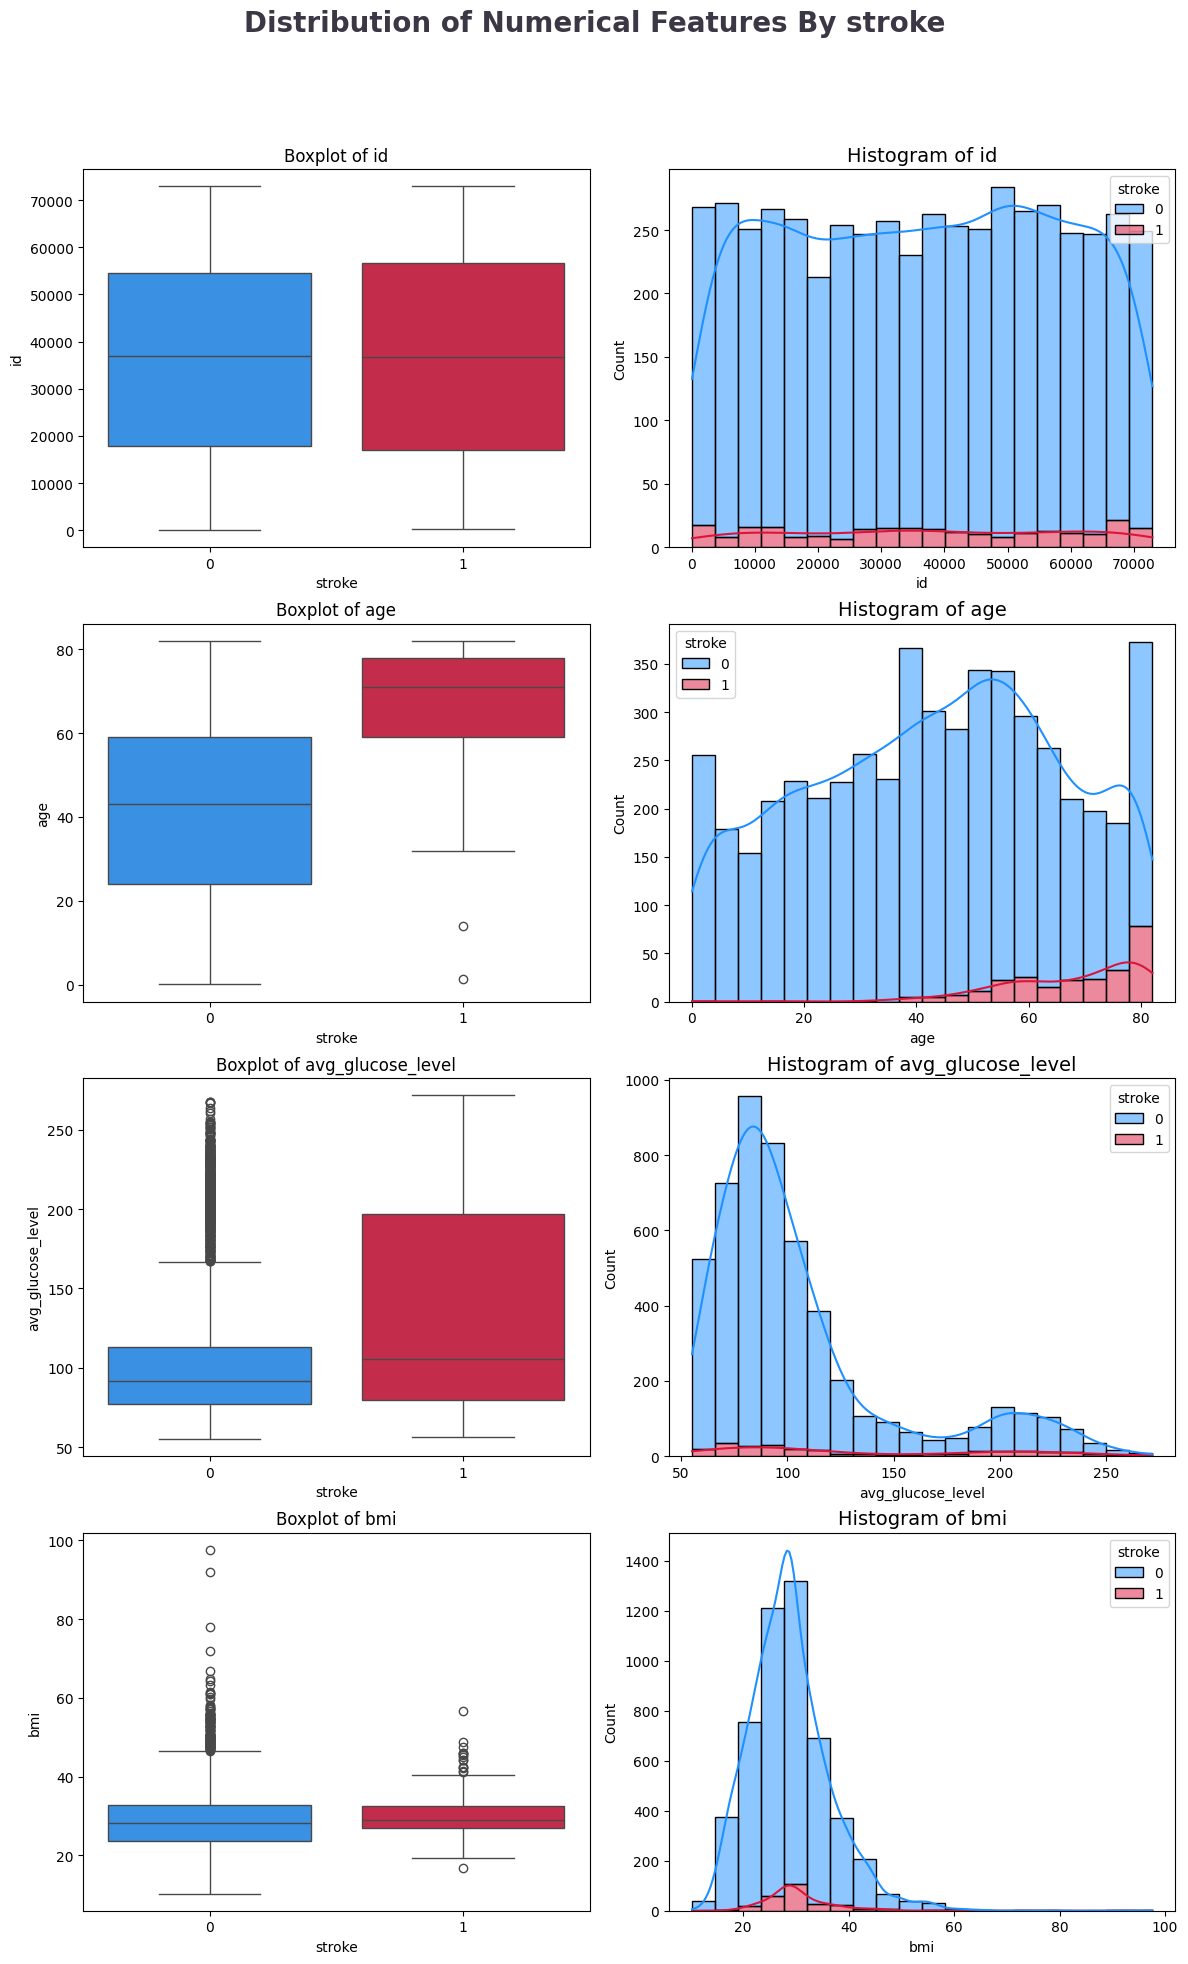

In [58]:
clr1 = ['#1E90FF', '#DC143C']
fig, ax = plt.subplots(4, 2, figsize=(12,20))
fig.suptitle('Distribution of Numerical Features By stroke', color='#3C3744',
             fontsize=20, fontweight='bold', ha='center')
for i, col in enumerate(continuous_features):   
    sns.boxplot(data=data, x='stroke', y=col,  palette=clr1, ax=ax[i,0])
    ax[i,0].set_title(f'Boxplot of {col}', fontsize=12)
    sns.histplot(data=data, x=col, hue='stroke', bins=20, kde=True, 
                 multiple='stack', palette=clr1, ax=ax[i,1])
    ax[i,1].set_title(f'Histogram of {col}', fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.90)
# plt.savefig('images/multivariate_num.png')

**Report**
* In the `id` column has unique value for each row, it can be ignored as a feature.
* Higher `age` group people have higher chance of heart stroke
* Higher the `avg_glucose_level` higher will be the chance of stroke.
* `bmi` have not much of a influence on the heart stroke may be because of missing values.

## Initial Analysis Report

* **There are missing values in the `bmi`.**
* **The `id` column can be deleted because each row has unique values.**
* **`Resident_type` and `Gender` columns are not correlated with `stroke` (Target Column)**
* **The `stroke` column is the target to predict.**

## 4. Visualization

### 4.1 Visualize the Target Feature

In [64]:
df1 = data.copy()
df1['stroke'] = np.where((data.stroke == 1),'Stroke', 'Not-Stroke' )

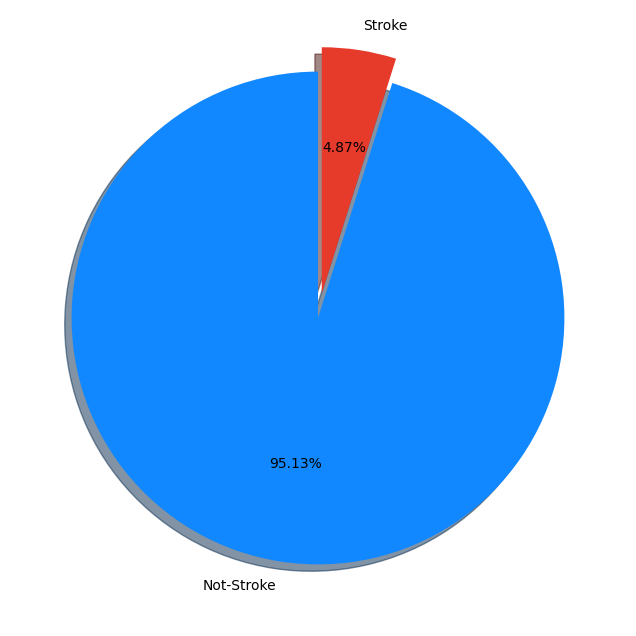

In [65]:
percentage = df1.stroke.value_counts(normalize=True)*100
label = ["Not-Stroke", "Stroke"]

# Plot PieChart with Ploty library
fig, ax = plt.subplots(figsize =(15, 8))
explode = (0, 0.1)
colors = ['#1188ff', '#e63a2a']
ax.pie(percentage, labels = label, startangle = 90,
       autopct='%1.2f%%',explode=explode, shadow=True, colors=colors)
plt.show()

* From the chart it is clear that the Target Variable is Imbalanced

**What is imbalanced data?**

Imbalanced data are types of data where the target class has an uneven distribution of observations, i.e Here number of Not-stroke has more count than the number of stroke of the dataset.

### 4.2 Do Men or Women have more chance of stroke?

In [68]:
df1.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [69]:
df1[df1.stroke == 'Stroke'].gender.value_counts(normalize=True)

gender
Female    0.566265
Male      0.433735
Name: proportion, dtype: float64

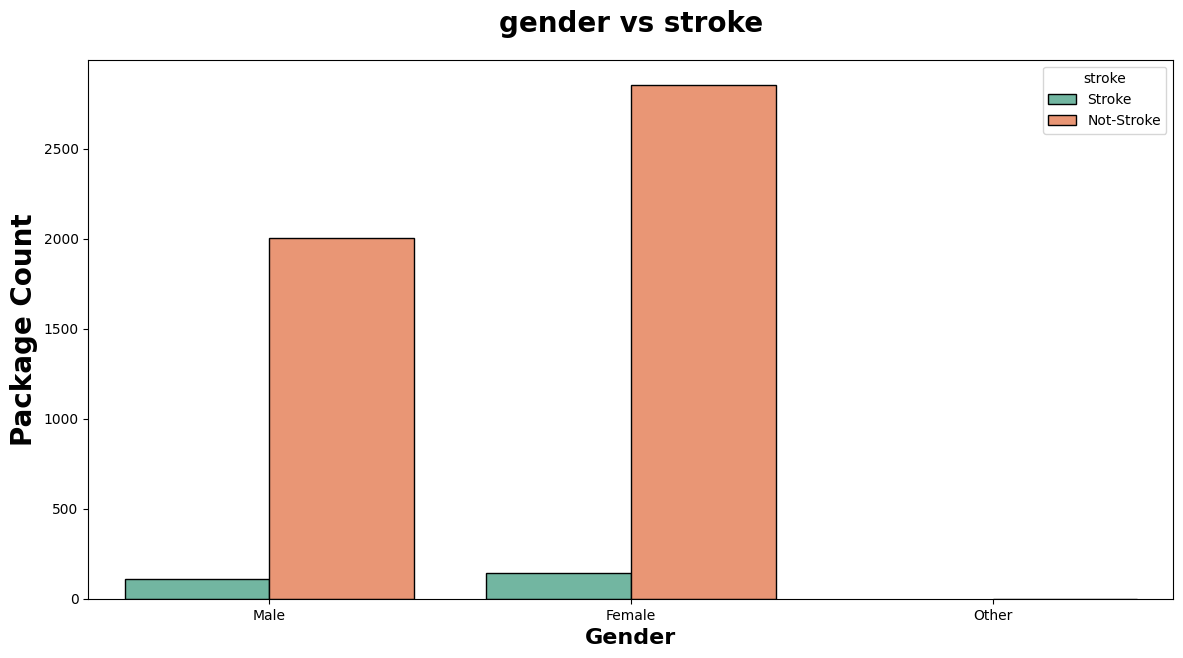

In [70]:
plt.subplots(figsize=(14,7))
sns.countplot(x="gender",hue="stroke", data=df1,ec = "black",palette="Set2")
plt.title("gender vs stroke", weight="bold",fontsize=20, pad=20)
plt.ylabel("Package Count", weight="bold", fontsize=20)
plt.xlabel("Gender", weight="bold", fontsize=16)
plt.show()

**insights**
* As per the chart there is no much difference between the stroke of male and female.
* This Feature has no impact on the Target Variable.

* **The Insights from Chi2 test is that gender column is not correlated with target column. Which is justified by above chart**r

### 4.3 AGE Category Split

In [74]:
bins= [0,10,20,50,85]
labels = ['Children','Teens','Adult','Senior']
df2 = data.copy()
df2['age_cat'] = pd.cut(data['age'], bins=bins, labels=labels, right=False)
age_group = df2.groupby(['age_cat', 'stroke'])['id'].count().reset_index(name='count')
age_group

C:\Users\Sneha\AppData\Local\Temp\ipykernel_21496\1964022855.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group = df2.groupby(['age_cat', 'stroke'])['id'].count().reset_index(name='count')


,age_cat,stroke,count
0,Children,0,471
1,Children,1,1
2,Teens,0,493
3,Teens,1,1
4,Adult,0,1916
5,Adult,1,18
6,Senior,0,1981
7,Senior,1,229


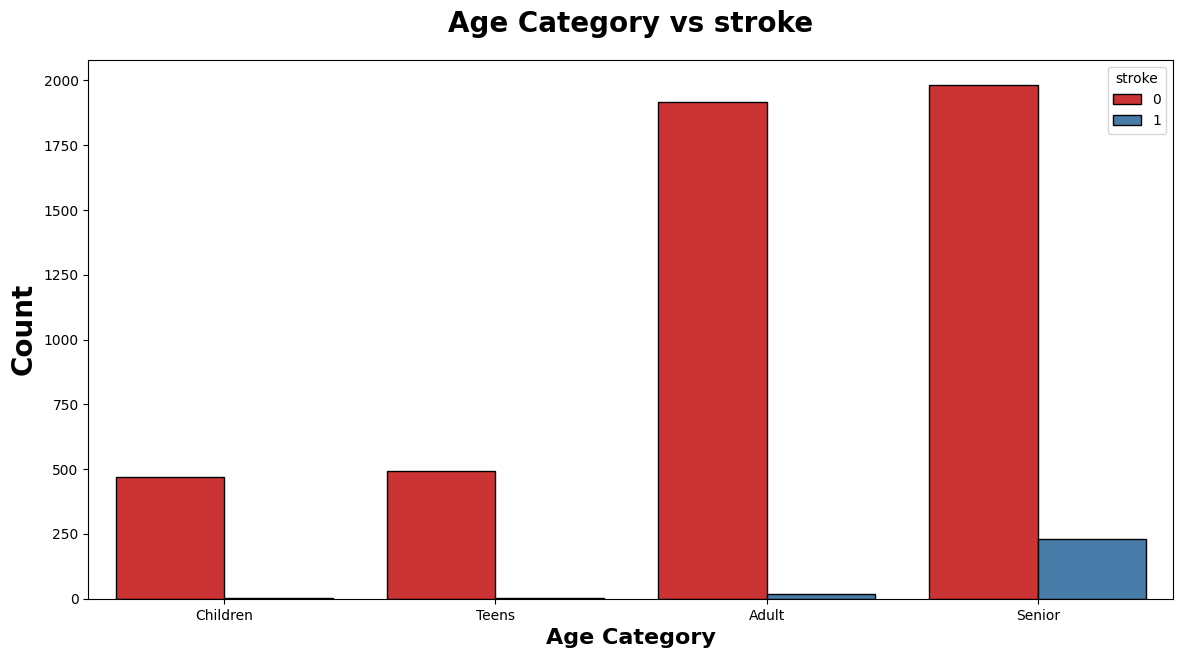

In [75]:
plt.subplots(figsize=(14,7))
sns.countplot(x="age_cat",hue="stroke", data=df2,ec = "black",palette="Set1")
plt.title("Age Category vs stroke", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=20)
plt.xlabel("Age Category", weight="bold", fontsize=16)
plt.show()

**Report:**
* As per the Chart Senior age Group has the more chance of heart stroke followed by adults.
* Children and teen have least chance of the stroke because of high physical activity.

C:\Users\Sneha\AppData\Local\Temp\ipykernel_21496\3283952011.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  count = order1[n]


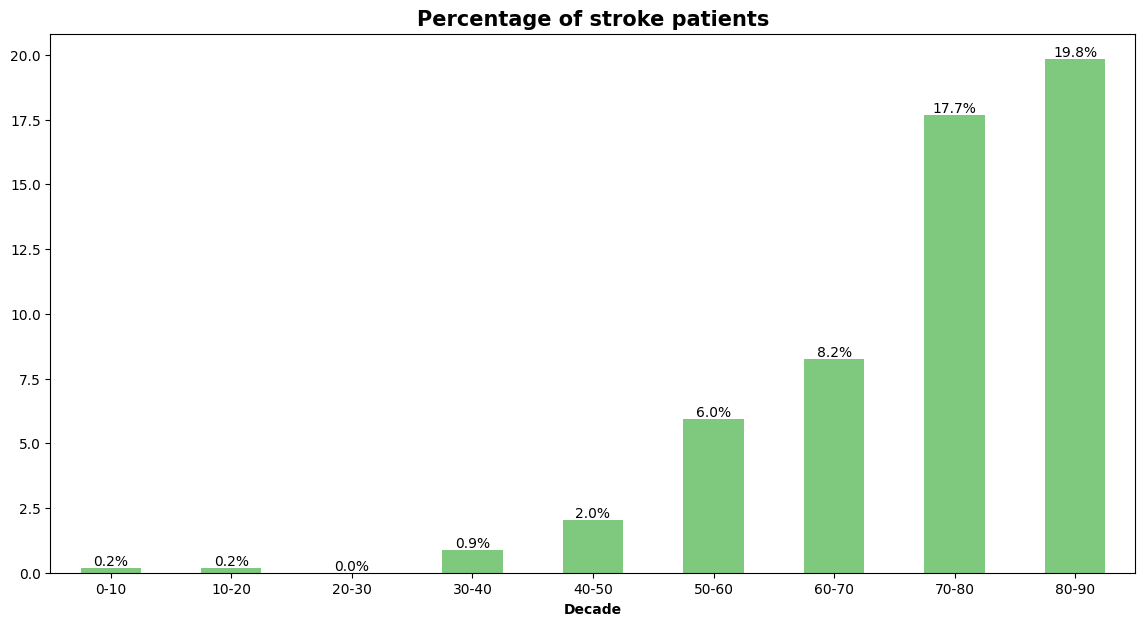

In [77]:
df2= data.copy()
bins=[0,10,20,30,40,50,60,70,80,90]
labels=['0-10','10-20','20-30','30-40','40-50','50-60','60-70','70-80','80-90']
df2['age_group']=pd.cut(data['age'],bins=bins,labels=labels)

import matplotlib.ticker as mtick

plt.figure(figsize=[14,7])

(100*df2[df2["stroke"].isin([1])]['age_group'].value_counts()/df2['age_group'].value_counts()).plot(
    kind='bar',stacked=True , colormap='Accent')
plt.title("Percentage of stroke patients" , fontsize = 15, fontweight ='bold'  )
order1 = (100*df2[df2["stroke"].isin([1])]['age_group'].value_counts()/df2['age_group'].value_counts())
for n in range(order1.shape[0]):
    count = order1[n]
    strt='{:0.1f}%'.format(count)
    plt.text(n,count+0.1,strt,ha='center')

plt.xlabel('Decade' , fontweight ='bold')
plt.xticks(rotation=0)
plt.show()

**Report**
* As the age increases there is higher chance of heart stroke.

### 4.4 Does HyperTension makes any difference

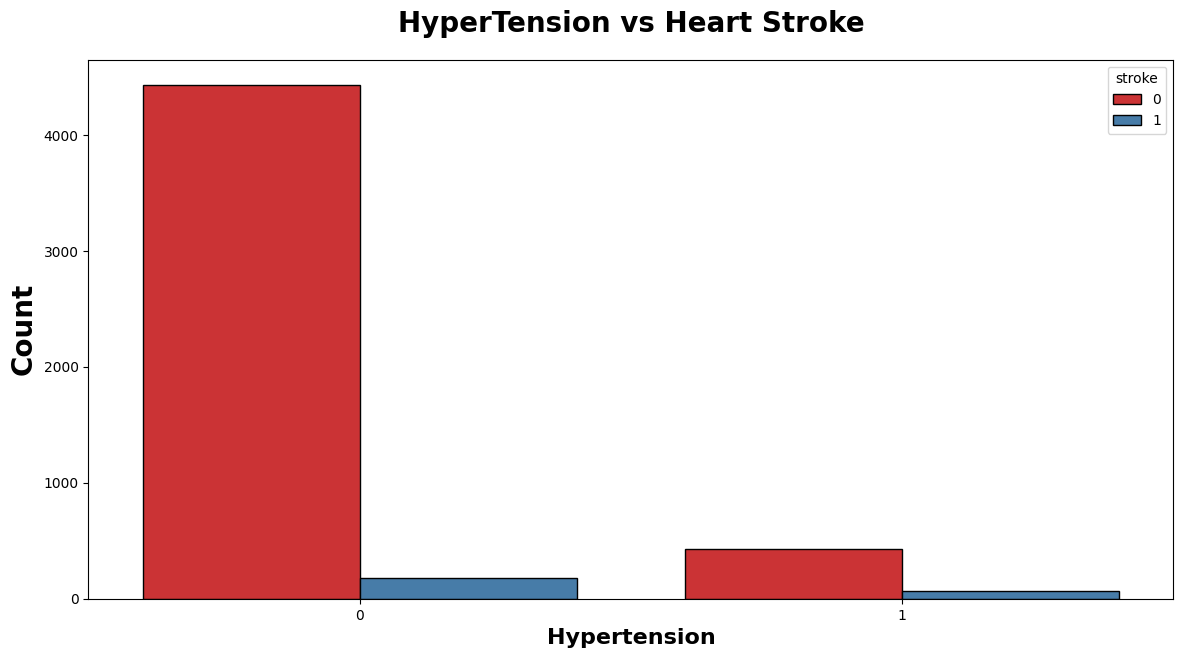

In [80]:
plt.subplots(figsize=(14,7))
sns.countplot(x="hypertension", data=df2,ec = "black",palette="Set1", hue='stroke')
plt.title("HyperTension vs Heart Stroke", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=20)
plt.xlabel("Hypertension", weight="bold", fontsize=16)
plt.show()

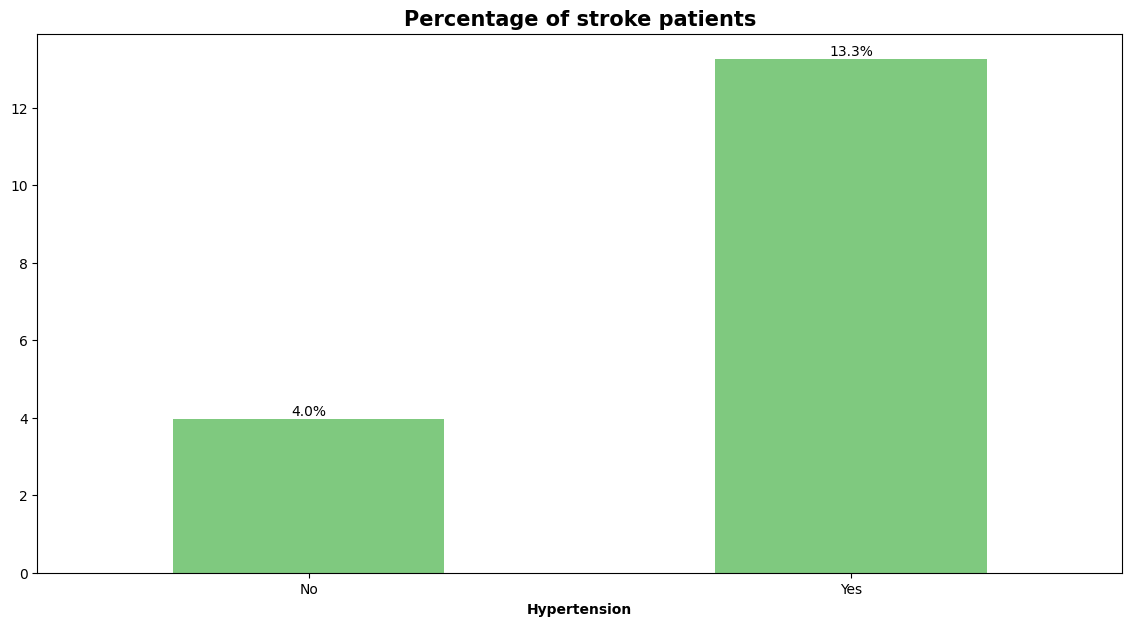

In [81]:
plt.subplots(figsize=(14,7))

(100*df2[df2["stroke"].isin([1])]['hypertension'].value_counts()/df2['hypertension'].value_counts()).plot(
    kind='bar',stacked=True , colormap='Accent')
plt.title("Percentage of stroke patients" , fontsize = 15, fontweight ='bold'  )
order1 = (100*df2[df2["stroke"].isin([1])]['hypertension'].value_counts()/df2['hypertension'].value_counts())
for n in range(order1.shape[0]):
    count = order1[n]
    strt='{:0.1f}%'.format(count)
    plt.text(n,count+0.1,strt,ha='center')
    
plt.xlabel('Hypertension' , fontweight ='bold')
plt.xticks(ticks=[0,1], labels=['No', 'Yes'] ,rotation=0)
plt.show()

**Insights**

* Evne though the patients with no hypertension and having chance of stroke are high but remember the data is imbalanced
* In comparision with the number of plople in both categories patients with hypertension have more chance of stroke.

## 4.5 Impact of BMI

#### BMI parameter can be divided into four categories [ Under_weight / Normal_weight / Over_weight / Obese ] 

The Categories of BMI :

- Under_weight ( BMI < 18.5 )
- Normal_weight ( 18.5 < BMI < 25 )
- Over_weight ( 25 < BMI < 30 )
- Obese ( BMI > 30 )

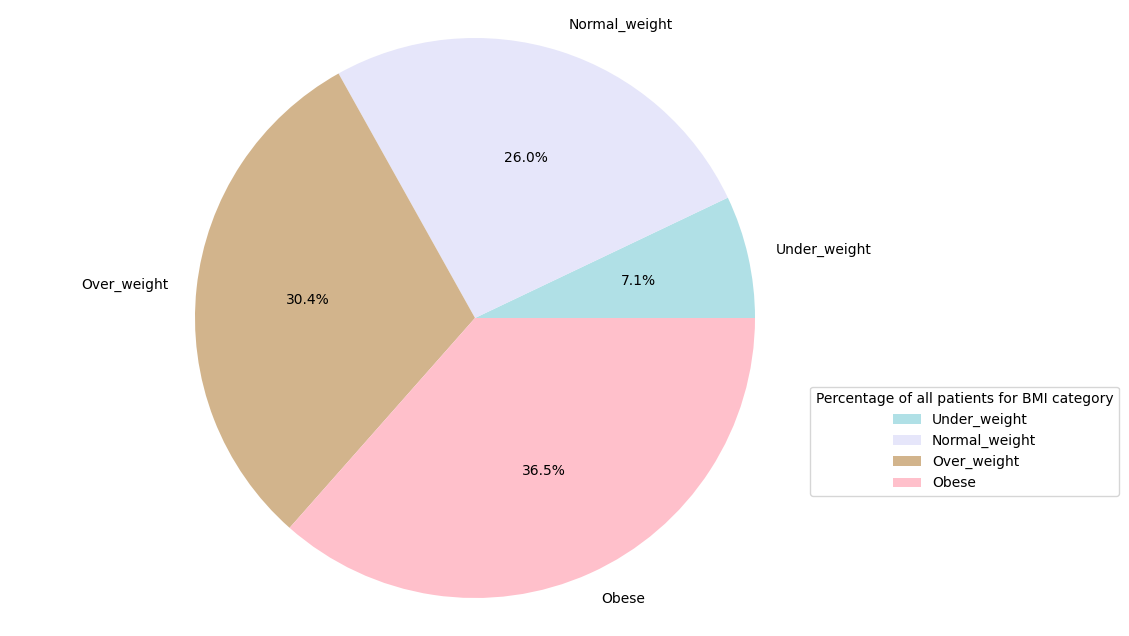

In [86]:
fig1, ax1 = plt.subplots(figsize=(12,8))
ax1.pie(x=[data[data['bmi'] <= 18.5]['stroke'].value_counts()[0] , 
data[(data['bmi'] <= 25) & (data['bmi'] > 18)]['stroke'].value_counts()[0] , 
data[(data['bmi'] <= 30) & (data['bmi'] > 25)]['stroke'].value_counts()[0] , 
data[data['bmi'] > 30]['stroke'].value_counts()[0] ], 
labels=['Under_weight','Normal_weight','Over_weight','Obese'] , 
pctdistance=0.6 , radius=6  , autopct='%1.1f%%' , 
colors=['powderblue','lavender','tan','pink'] )

ax1.axis('equal')
plt.legend(title = "Percentage of all patients for BMI category" , loc=1 , bbox_to_anchor=(1.2, 0.4))
plt.show() 

**Insights:**
* We have most number of obese patients followed by the Over_weight totally comprises of nearly 65% of the total patients.
* We have leat number of patients with underweight

In [88]:
df2= data.copy()
bins=[0,18,25,30,100]
labels=['0-18','18-25','25-30','30-100']
df2['bmi_cat']=pd.cut(data['bmi'],bins=bins,labels=labels)
bmi_group = df2.groupby(['bmi_cat', 'stroke'])['id'].count().reset_index(name='count')
bmi_group

C:\Users\Sneha\AppData\Local\Temp\ipykernel_21496\114376804.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmi_group = df2.groupby(['bmi_cat', 'stroke'])['id'].count().reset_index(name='count')


,bmi_cat,stroke,count
0,0-18,0,288
1,0-18,1,1
2,18-25,0,1281
3,18-25,1,37
4,25-30,0,1495
5,25-30,1,115
6,30-100,0,1797
7,30-100,1,96


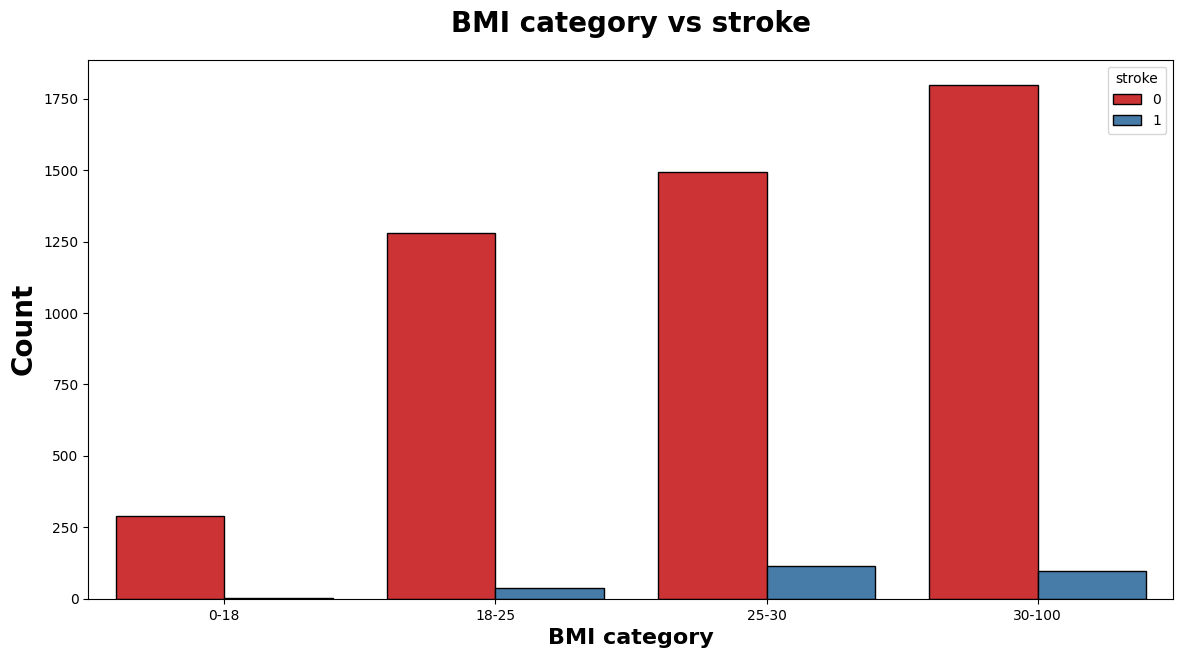

In [89]:
plt.subplots(figsize=(14,7))
sns.countplot(x="bmi_cat",hue="stroke", data=df2,ec = "black",palette="Set1")
plt.title("BMI category vs stroke", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=20)
plt.xlabel("BMI category", weight="bold", fontsize=16)
plt.show()

**Insights**

* we can see as the BMI increses there is a high chance of stroke. Implies that the obese and overweight people have hight chance of stroke.

C:\Users\Sneha\AppData\Local\Temp\ipykernel_21496\2253102219.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  count = order1[n]


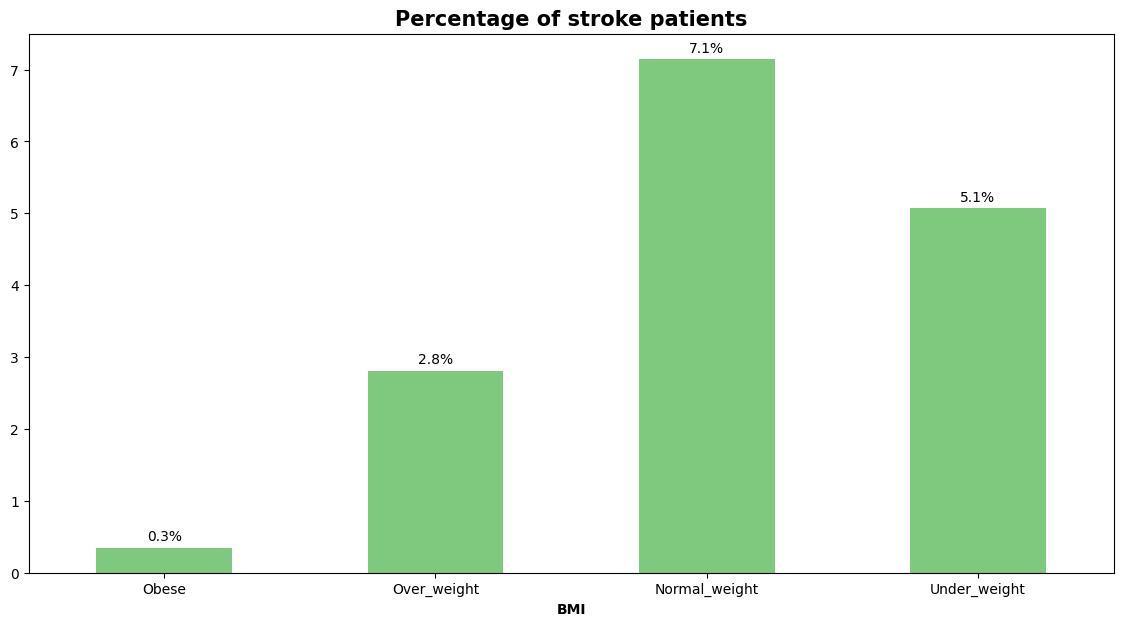

In [91]:
plt.subplots(figsize=(14,7))

(100*df2[df2["stroke"].isin([1])]['bmi_cat'].value_counts()/df2['bmi_cat'].value_counts()).plot(
    kind='bar',stacked=True , colormap='Accent')
plt.title("Percentage of stroke patients" , fontsize = 15, fontweight ='bold'  )
order1 = (100*df2[df2["stroke"].isin([1])]['bmi_cat'].value_counts()/df2['bmi_cat'].value_counts())
for n in range(order1.shape[0]):
    count = order1[n]
    strt='{:0.1f}%'.format(count)
    plt.text(n,count+0.1,strt,ha='center')
    
plt.xlabel('BMI' , fontweight ='bold')
plt.xticks(ticks=[0,1,2,3], labels=['Under_weight','Normal_weight','Over_weight','Obese'][::-1] ,rotation=0)
plt.show()

* Obese and overweight people have more chance of heart stroke.

### 4.6 Heark disease vs Stroke

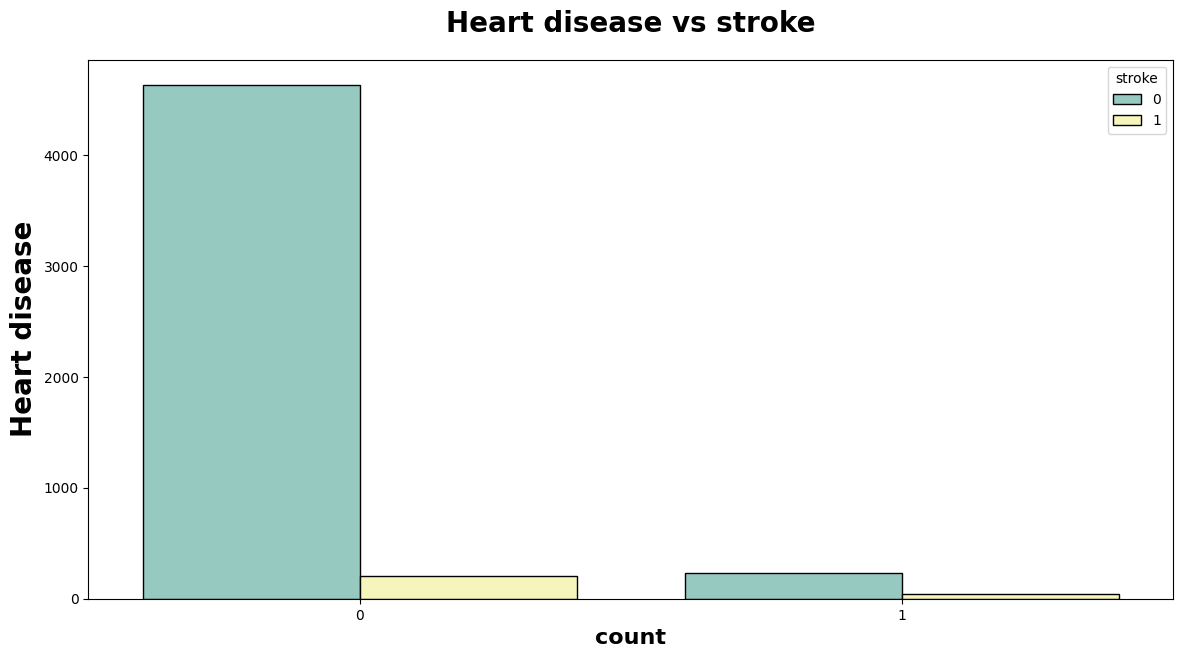

In [94]:
plt.subplots(figsize=(14,7))
sns.countplot(x="heart_disease",hue='stroke', data=data,ec = "black",palette="Set3")
plt.title("Heart disease vs stroke", weight="bold",fontsize=20, pad=20)
plt.ylabel("Heart disease", weight="bold", fontsize=20)
plt.xlabel("count", weight="bold", fontsize=16)
plt.show()

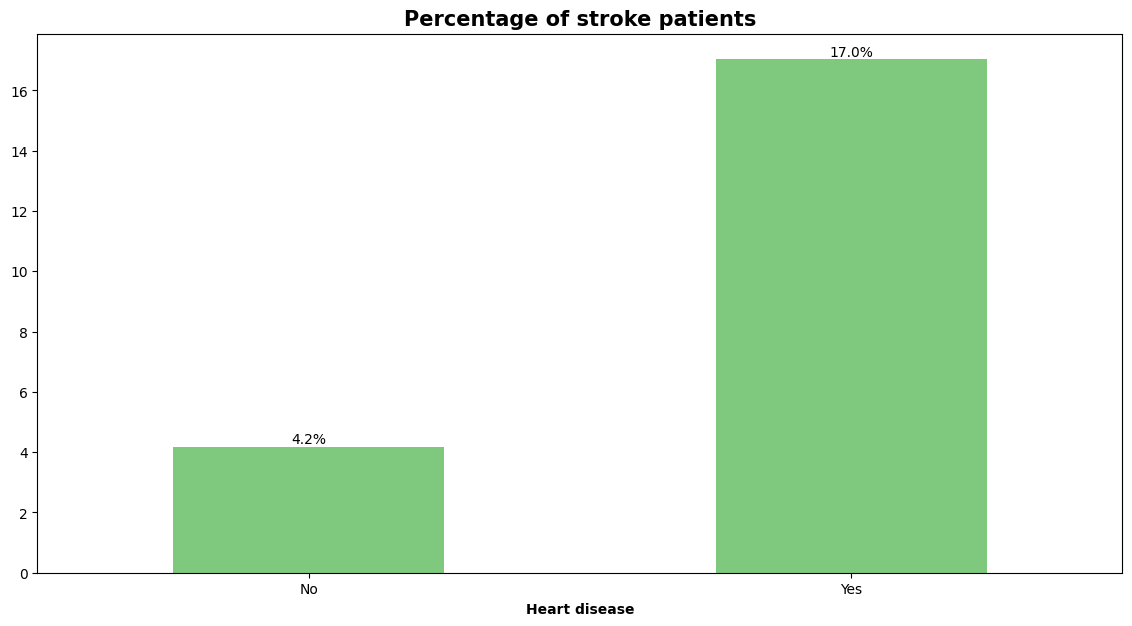

In [95]:
plt.subplots(figsize=(14,7))

(100*df2[df2["stroke"].isin([1])]['heart_disease'].value_counts()/df2['heart_disease'].value_counts()).plot(
    kind='bar',stacked=True , colormap='Accent')
plt.title("Percentage of stroke patients" , fontsize = 15, fontweight ='bold'  )
order1 = (100*df2[df2["stroke"].isin([1])]['heart_disease'].value_counts()/df2['heart_disease'].value_counts())
for n in range(order1.shape[0]):
    count = order1[n]
    strt='{:0.1f}%'.format(count)
    plt.text(n,count+0.1,strt,ha='center')
    
plt.xlabel('Heart disease' , fontweight ='bold')
plt.xticks(ticks=[0,1], labels=['No', 'Yes'] ,rotation=0)
plt.show()

**Insights**

* Patients with heart disease have high chance of heart attack the the healty people.

## 4.7- Does marriage have any effect on the stroke

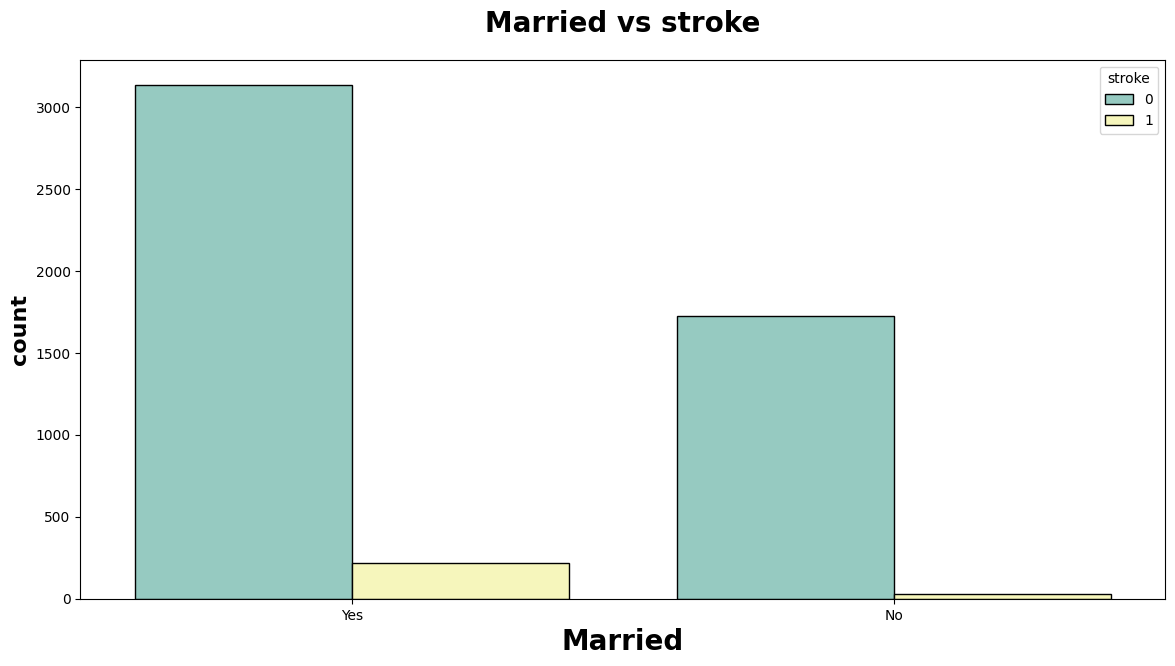

In [98]:
plt.subplots(figsize=(14,7))
sns.countplot(x="ever_married",hue='stroke', data=data,ec = "black",palette="Set3")
plt.title("Married vs stroke", weight="bold",fontsize=20, pad=20)
plt.xlabel("Married", weight="bold", fontsize=20)
plt.ylabel("count", weight="bold", fontsize=16)
plt.show()

C:\Users\Sneha\AppData\Local\Temp\ipykernel_21496\2606572187.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  count = order1[n]


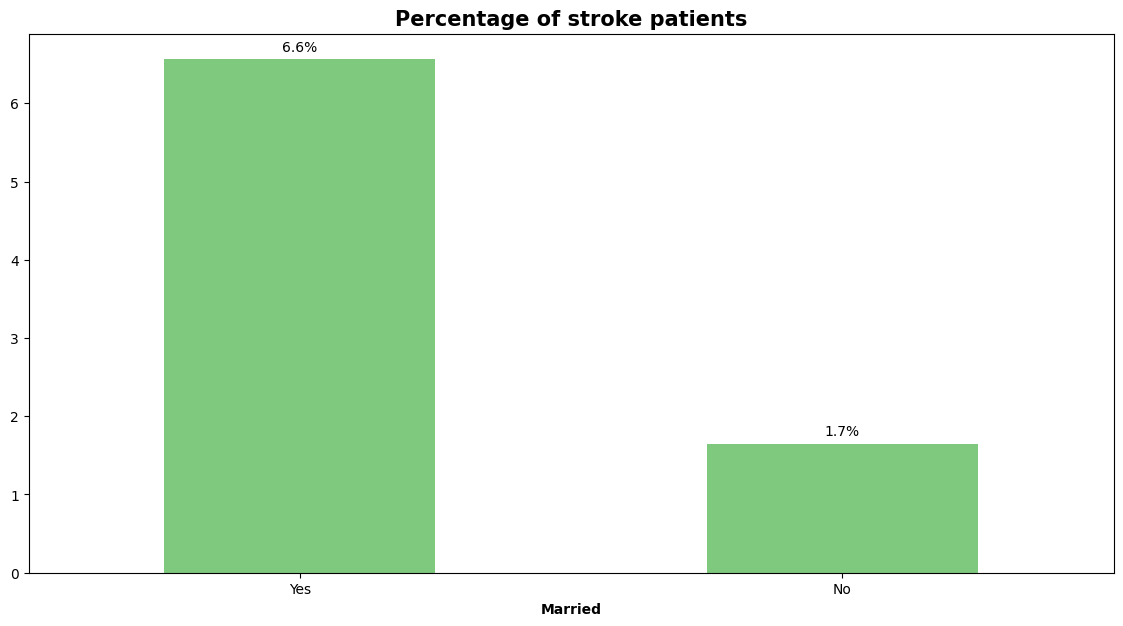

In [99]:
plt.subplots(figsize=(14,7))

(100*df2[df2["stroke"].isin([1])]['ever_married'].value_counts()/df2['ever_married'].value_counts()).plot(
    kind='bar',stacked=True , colormap='Accent')
plt.title("Percentage of stroke patients" , fontsize = 15, fontweight ='bold'  )
order1 = (100*df2[df2["stroke"].isin([1])]['ever_married'].value_counts()/df2['ever_married'].value_counts())
for n in range(order1.shape[0]):
    count = order1[n]
    strt='{:0.1f}%'.format(count)
    plt.text(n,count+0.1,strt,ha='center')
    
plt.xlabel('Married' , fontweight ='bold')
plt.xticks(ticks=[0,1], labels=['Yes', 'No'] ,rotation=0)
plt.show()

**Insights**

* Surprisingly married people have more chance of stroke which doesnt make any sense.
* It may because the married peple are aged than the unmarried and age is factor playing major role.

## 4.8 Work type vs Stroke

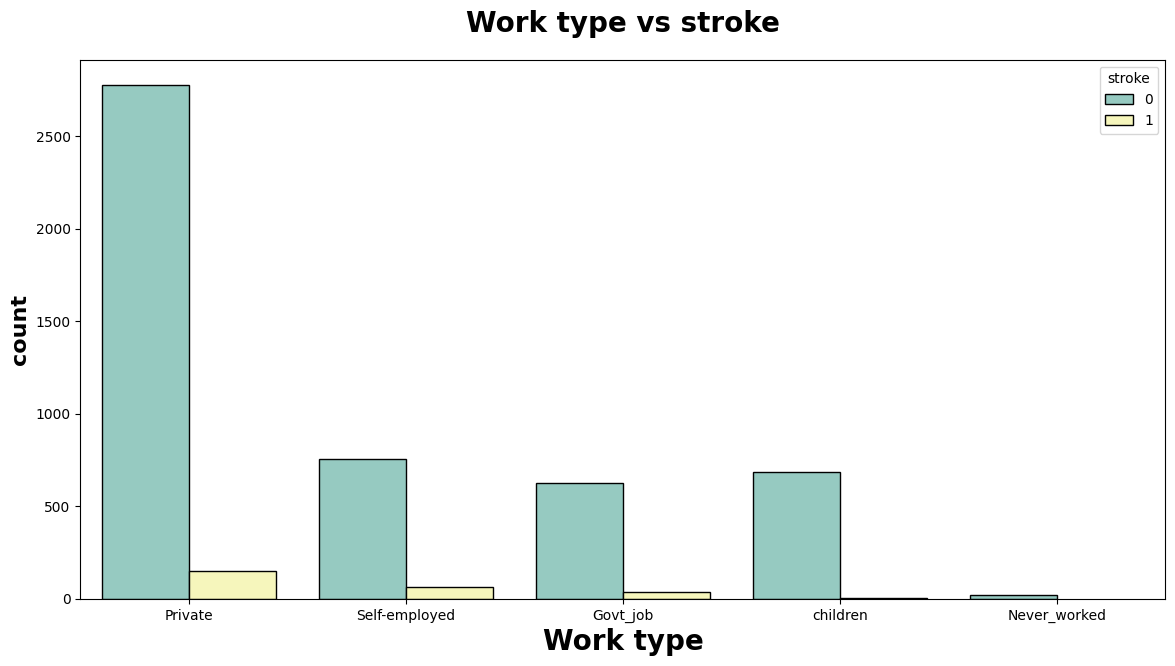

In [102]:
plt.subplots(figsize=(14,7))
sns.countplot(x="work_type",hue='stroke', data=data,ec = "black",palette="Set3")
plt.title("Work type vs stroke", weight="bold",fontsize=20, pad=20)
plt.xlabel("Work type", weight="bold", fontsize=20)
plt.ylabel("count", weight="bold", fontsize=16)
plt.show()

* `children` would have not worked so can be added to `Never_worked` column.
* Hence we can change the `children` to `Never_worked`

In [104]:
df2 = data.copy()
df2['work_type'] = np.where(df2['work_type'] == 'children', 'Never_worked', df2['work_type'])

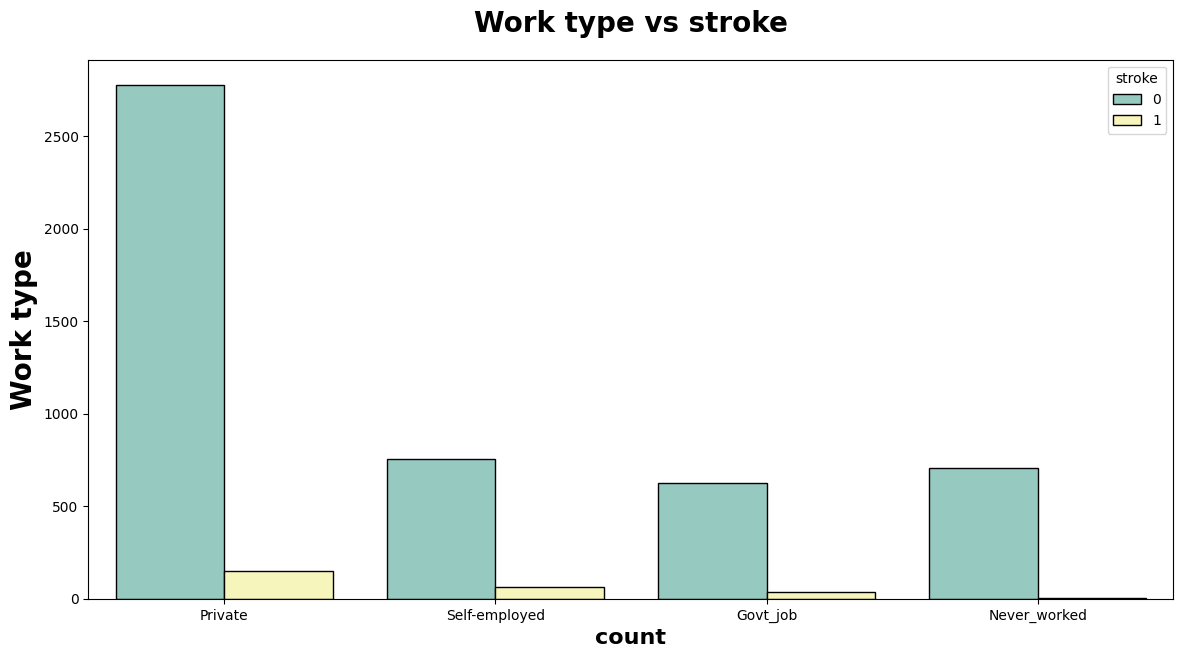

In [105]:
plt.subplots(figsize=(14,7))
sns.countplot(x="work_type",hue='stroke', data=df2,ec = "black",palette="Set3")
plt.title("Work type vs stroke", weight="bold",fontsize=20, pad=20)
plt.ylabel("Work type", weight="bold", fontsize=20)
plt.xlabel("count", weight="bold", fontsize=16)
plt.show()

C:\Users\Sneha\AppData\Local\Temp\ipykernel_21496\2294447487.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  count = order1[n]


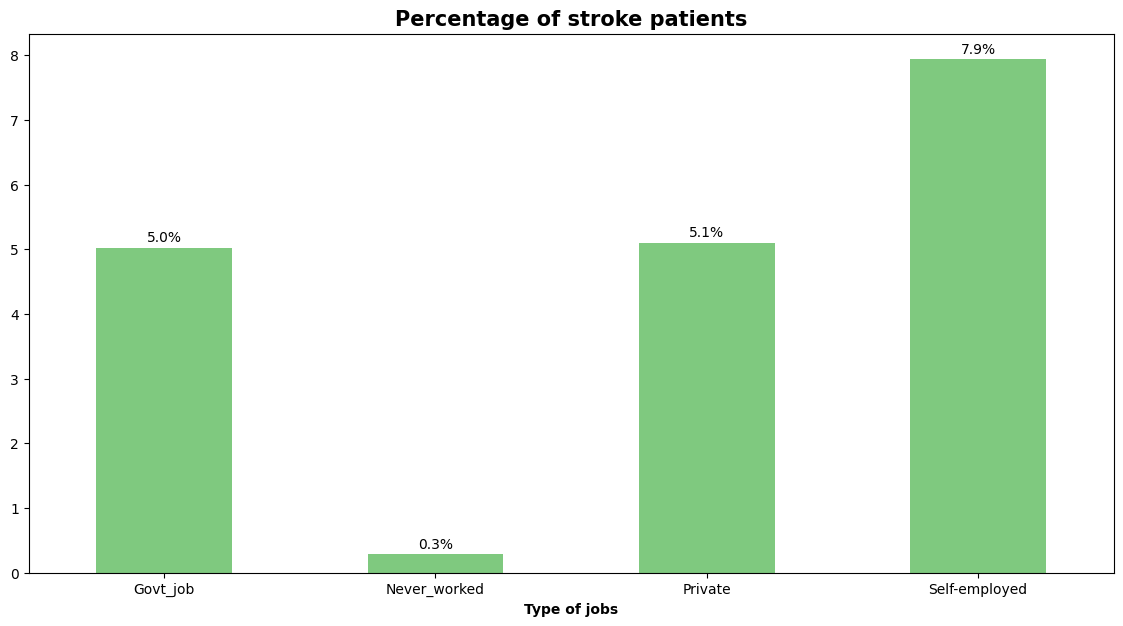

In [106]:
plt.subplots(figsize=(14,7))

(100*df2[df2["stroke"].isin([1])]['work_type'].value_counts()/df2['work_type'].value_counts()).plot(
    kind='bar',stacked=True , colormap='Accent' )
plt.title("Percentage of stroke patients" , fontsize = 15, fontweight ='bold'  )
order1 = (100*df2[df2["stroke"].isin([1])]['work_type'].value_counts()/df2['work_type'].value_counts())
for n in range(order1.shape[0]):
    count = order1[n]
    strt='{:0.1f}%'.format(count)
    plt.text(n,count+0.1,strt,ha='center')
    
plt.xlabel('Type of jobs' , fontweight ='bold')
plt.xticks(rotation=0)
plt.show()

**Insights**

* Self-employed patients have high chance of heart stroke.
* Government and provate job employes have nearly same chance of heart stroke.
* Unemployed and children have least or near zero chance of stroke.

## 4.9- Resident type vs stroke

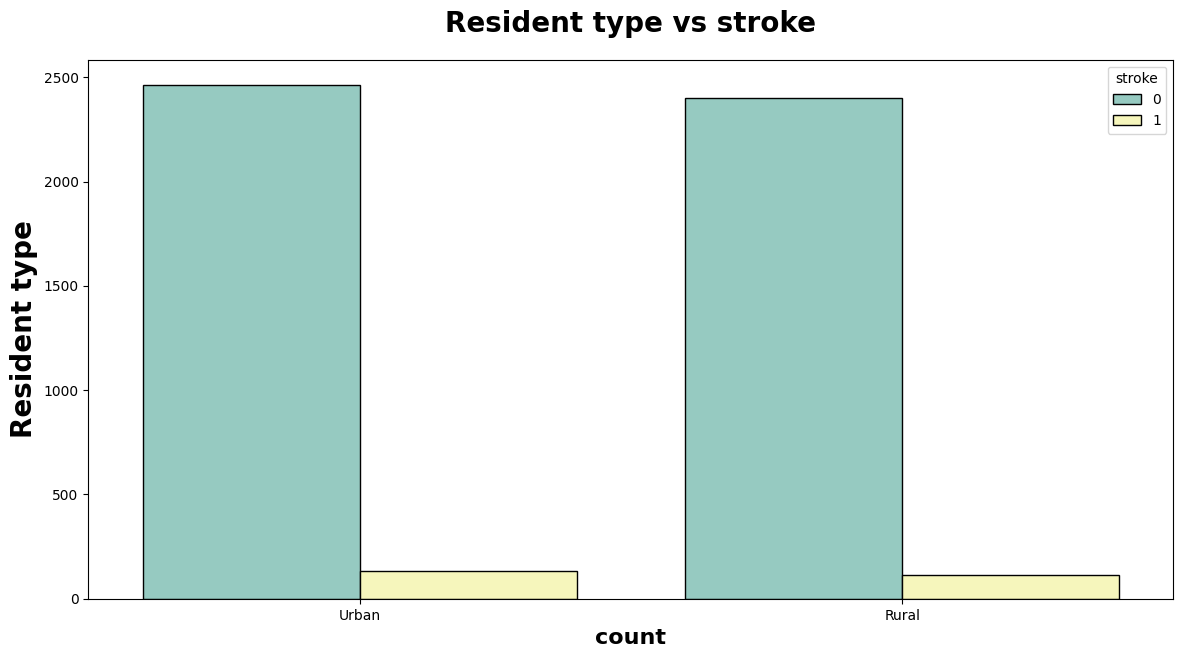

In [109]:
plt.subplots(figsize=(14,7))
sns.countplot(x="Residence_type",hue='stroke', data=df2,ec = "black",palette="Set3")
plt.title("Resident type vs stroke", weight="bold",fontsize=20, pad=20)
plt.ylabel("Resident type", weight="bold", fontsize=20)
plt.xlabel("count", weight="bold", fontsize=16)
plt.show()

C:\Users\Sneha\AppData\Local\Temp\ipykernel_21496\2642224183.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  count = order1[n]


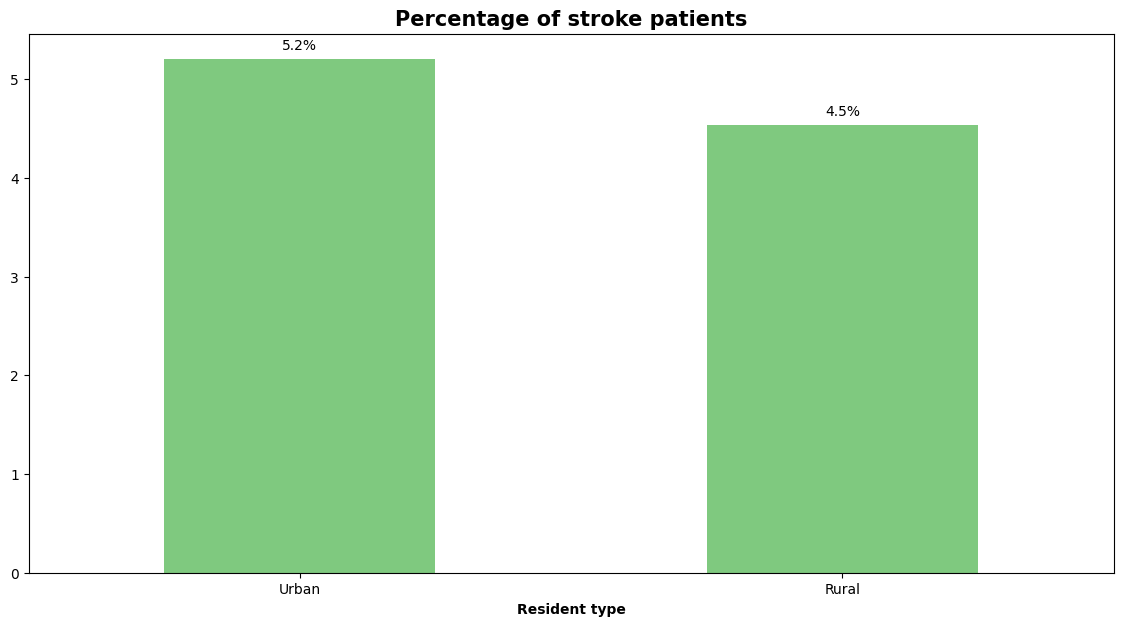

In [110]:
plt.subplots(figsize=(14,7))

(100*df2[df2["stroke"].isin([1])]['Residence_type'].value_counts()/df2['Residence_type'].value_counts()).plot(kind='bar',stacked=True , colormap='Accent' )
plt.title("Percentage of stroke patients" , fontsize = 15, fontweight ='bold'  )
order1 = (100*df2[df2["stroke"].isin([1])]['Residence_type'].value_counts()/df2['Residence_type'].value_counts())
for n in range(order1.shape[0]):
    count = order1[n]
    strt='{:0.1f}%'.format(count)
    plt.text(n,count+0.1,strt,ha='center')
    
plt.xlabel('Resident type' , fontweight ='bold')
plt.xticks(rotation=0)
plt.show()

**Insights**

* Urban residents have silght edge over the rural residents here.
* It doesn't have much difference which is already confirmed by the chi2 contingency test

## 4.10- Effect of glucose level

<Axes: xlabel='avg_glucose_level', ylabel='Count'>

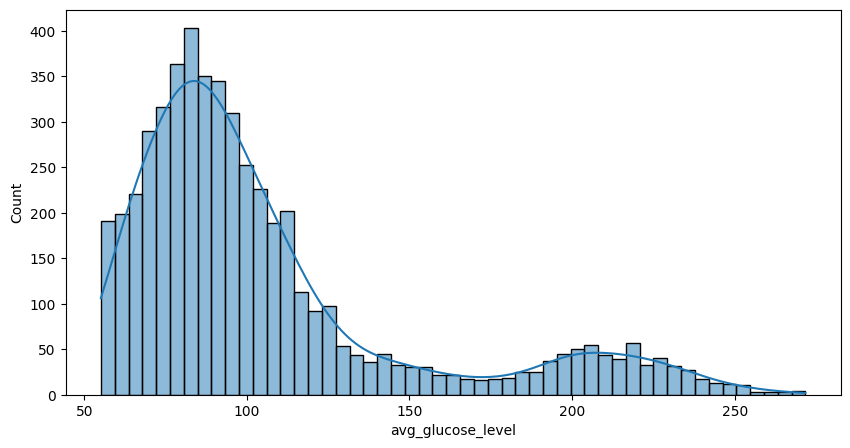

In [113]:
sns.histplot(data.avg_glucose_level,kde=True)

In [114]:
data.avg_glucose_level.min(), data.avg_glucose_level.max()

(55.12, 271.74)

In [115]:
bins= [0,70,140,200, 300]
labels = ['low','Normal','High','Diabetic']
df2 = data.copy()
df2['glucose_cat'] = pd.cut(data['avg_glucose_level'], bins=bins, labels=labels, right=False)
age_group = df2.groupby(['glucose_cat', 'stroke'])['id'].count().reset_index(name='count')
age_group

C:\Users\Sneha\AppData\Local\Temp\ipykernel_21496\3733526739.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group = df2.groupby(['glucose_cat', 'stroke'])['id'].count().reset_index(name='count')


,glucose_cat,stroke,count
0,low,0,727
1,low,1,27
2,Normal,0,3406
3,Normal,1,129
4,High,0,350
5,High,1,37
6,Diabetic,0,378
7,Diabetic,1,56


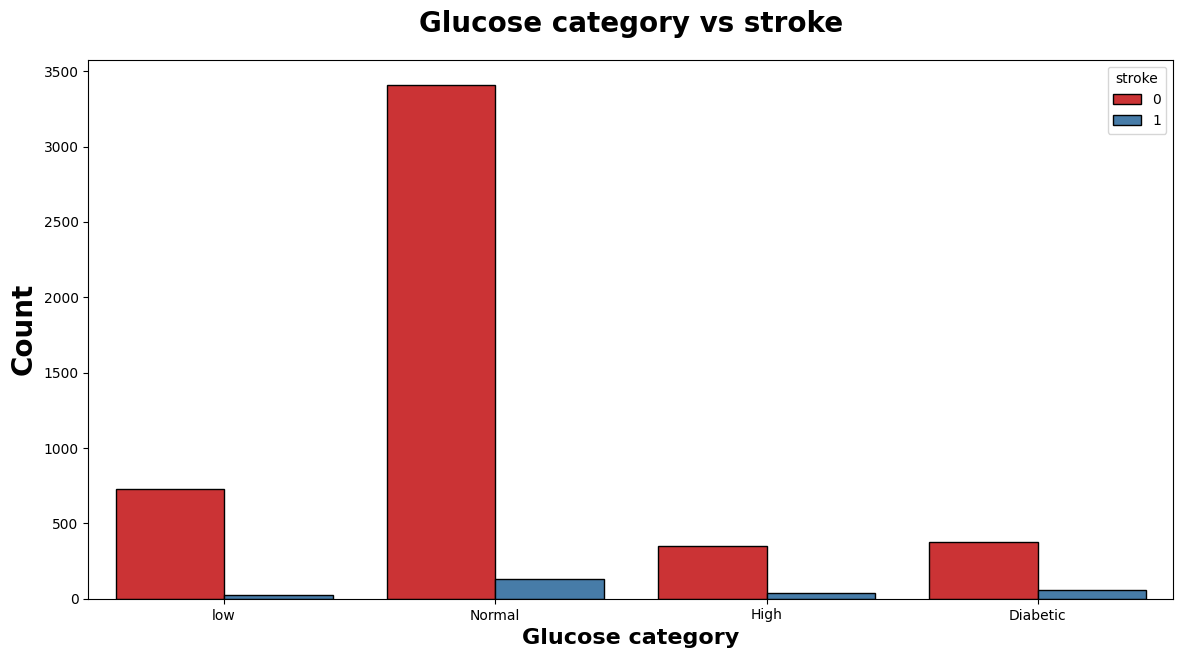

In [116]:
plt.subplots(figsize=(14,7))
sns.countplot(x="glucose_cat",hue="stroke", data=df2,ec = "black",palette="Set1")
plt.title("Glucose category vs stroke", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=20)
plt.xlabel("Glucose category", weight="bold", fontsize=16)
plt.show()

C:\Users\Sneha\AppData\Local\Temp\ipykernel_21496\115653062.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  count = order1[n]


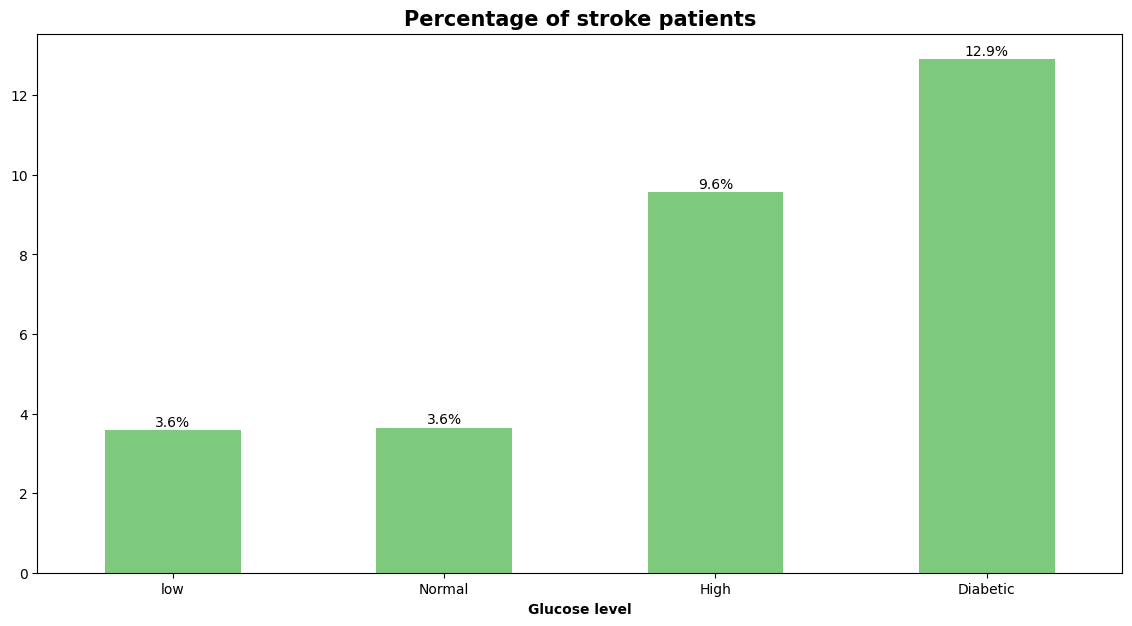

In [117]:
plt.subplots(figsize=(14,7))

(100*df2[df2["stroke"].isin([1])]['glucose_cat'].value_counts()/df2['glucose_cat'].value_counts()).plot(kind='bar',stacked=True , colormap='Accent' )
plt.title("Percentage of stroke patients" , fontsize = 15, fontweight ='bold'  )
order1 = (100*df2[df2["stroke"].isin([1])]['glucose_cat'].value_counts()/df2['glucose_cat'].value_counts())
for n in range(order1.shape[0]):
    count = order1[n]
    strt='{:0.1f}%'.format(count)
    plt.text(n,count+0.1,strt,ha='center')
    
plt.xlabel('Glucose level' , fontweight ='bold')
plt.xticks(ticks=[0,1,2,3], labels = ['low','Normal','High','Diabetic'] ,rotation=0)
plt.show()

**Insights**

* We can see that the patients with low or normal glucose levels have less chance of stroke.
* High chance of stroke is found in diabetic patients followed by high glucose level. 

## 4.11- smoking status vs stroke

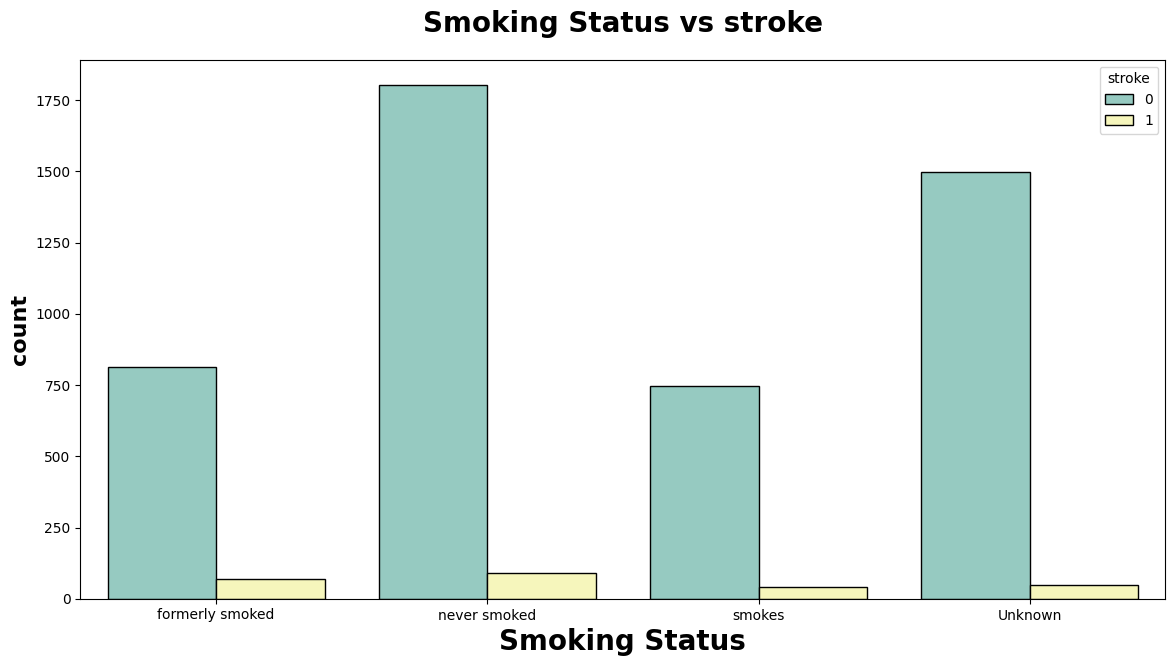

In [120]:
plt.subplots(figsize=(14,7))
sns.countplot(x="smoking_status",hue='stroke', data=df2,ec = "black",palette="Set3")
plt.title("Smoking Status vs stroke", weight="bold",fontsize=20, pad=20)
plt.xlabel("Smoking Status", weight="bold", fontsize=20)
plt.ylabel("count", weight="bold", fontsize=16)
plt.show()

C:\Users\Sneha\AppData\Local\Temp\ipykernel_21496\4173346.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  count = order1[n]


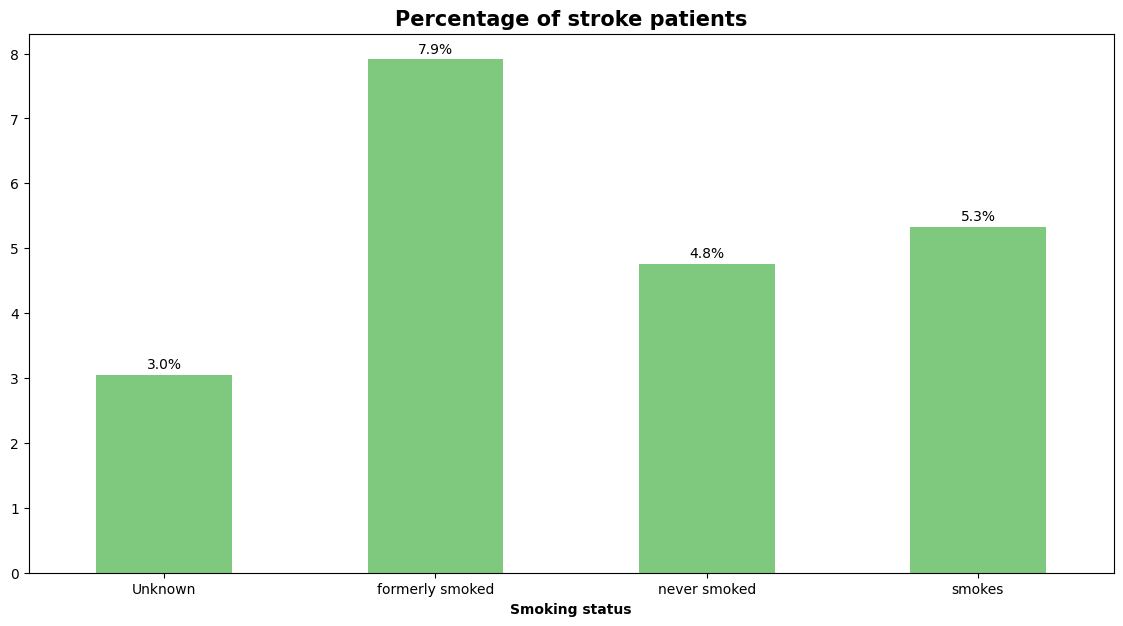

In [121]:
plt.subplots(figsize=(14,7))
(100*df2[df2["stroke"].isin([1])]['smoking_status'].value_counts()/df2['smoking_status'].value_counts()).plot(kind='bar',stacked=True , colormap='Accent' )
plt.title("Percentage of stroke patients" , fontsize = 15, fontweight ='bold'  )
order1 = (100*df2[df2["stroke"].isin([1])]['smoking_status'].value_counts()/df2['smoking_status'].value_counts())
for n in range(order1.shape[0]):
    count = order1[n]
    strt='{:0.1f}%'.format(count)
    plt.text(n,count+0.1,strt,ha='center')
    
plt.xlabel('Smoking status' , fontweight ='bold')
plt.xticks(rotation=0)
plt.show()

**Insights**

* `formerly_smoked` seems to have high chance of stroke may be because of long term effect of smoking.
* `smokes` and `never smoked` have nearly same chance
* smoking have a long term impact and may not be seen at the beginning stages.

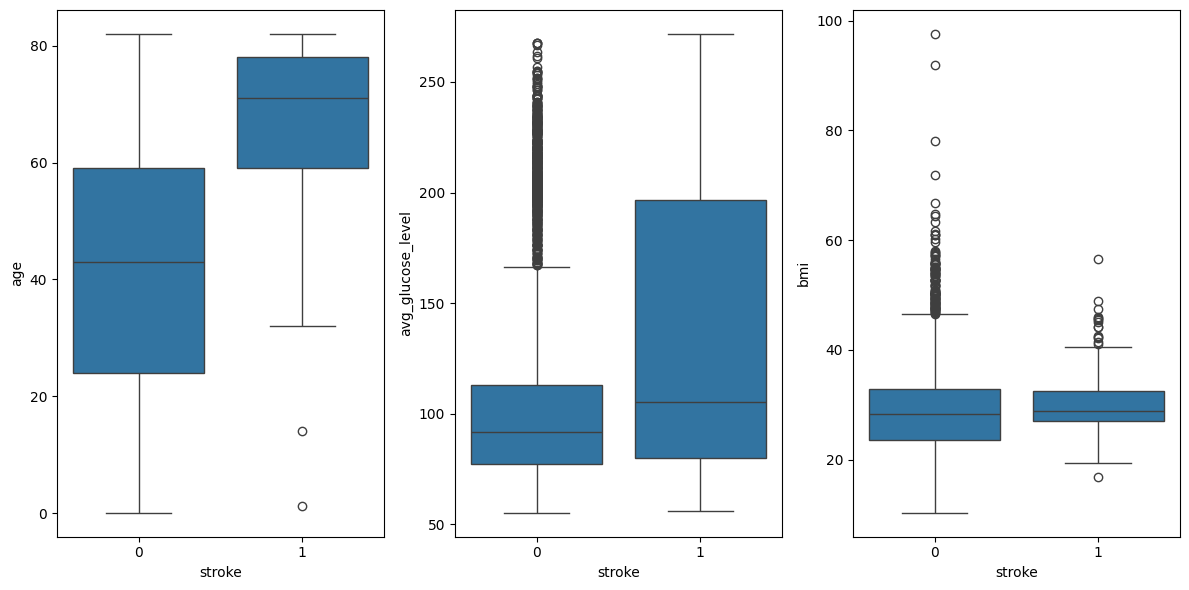

In [123]:
column_list = ['age', 'avg_glucose_level', 'bmi']

fig, ax = plt.subplots(1, 3, figsize=(12,6))

for i, col in enumerate(column_list):
  sns.boxplot(data=data, x='stroke', y=col, ax=ax[i])

plt.tight_layout()
plt.show()

## Final Report

* The `stroke` column is the target to predict.
* The target variable here is imbalanced, Handling imbalanced data is required.
* There are outliers in the `avg_glucose_level`, `bmi` columns.
* `Gender` and `Residence_type` has less or no effect on target column.
* Null values in `bmi` column should be handled.

# Data Pre-Processing

## Data Cleaning


In [128]:
data.drop('id',axis=1,inplace=True)
#remove id from the data as it is not useful it dosent afect anything
#axis=0 means the id is not in the rows so we give value 1 to indicate it is in the rows

In [129]:
data.duplicated().sum()

0

In [130]:
data

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80.0,1,0,Yes,Private,Urban,83.75,28.893237,never smoked,0
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.000000,never smoked,0
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.600000,never smoked,0
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.600000,formerly smoked,0


# 5) Outlier Removal

In [132]:
from matplotlib.pyplot import figure
figure(num=None, figsize=(8, 6), dpi=800, facecolor='w', edgecolor='k')

<Figure size 6400x4800 with 0 Axes>

<Figure size 6400x4800 with 0 Axes>

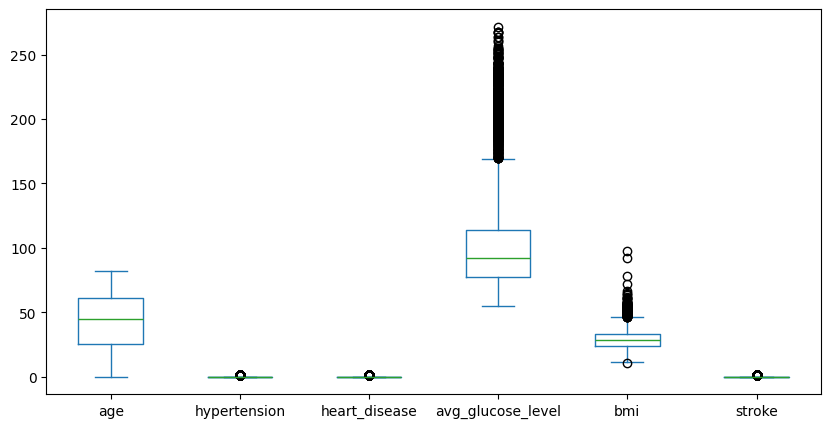

In [133]:
data.plot(kind='box')
plt.show()
#in this the box is the mean data and the black dot dots are the persons, we need to remove those or else our dayta will be very imbalanced.
#we have so many outliers.

# Feature Engeneering
### Type of Features
**Numeric Features**

In [135]:
numeric_features = [feature for feature in data.columns if data[feature].dtype != 'O']
print('Num of Numerical Features :', len(numeric_features))
numeric_features

Num of Numerical Features : 6


['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']

**Categorical Features**

In [137]:
categorical_features = [feature for feature in data.columns if data[feature].dtype == 'O']
print('Num of Categorical Features :', len(categorical_features))
categorical_features

Num of Categorical Features : 5


['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

**Discrete Features**

In [139]:
discrete_features=[feature for feature in numeric_features if (len(data[feature].unique())<=25)]
print('Num of Discrete Features :',len(discrete_features))
discrete_features

Num of Discrete Features : 3


['hypertension', 'heart_disease', 'stroke']

**Continuous Features**

In [141]:
continuous_features=[feature for feature in numeric_features if len(data[feature].unique()) > 25]
print('Num of Continuous Features :',len(continuous_features))
continuous_features

Num of Continuous Features : 3


['age', 'avg_glucose_level', 'bmi']

## Feature Transformation

In [143]:
data[continuous_features].skew(axis=0)

age                 -0.137059
avg_glucose_level    1.572284
bmi                  1.076716
dtype: float64

* **If Skewness is above 2 then the feature is Highly skewed**
* **If Skewness is above 1.5 then the feature is Moderately skewed**

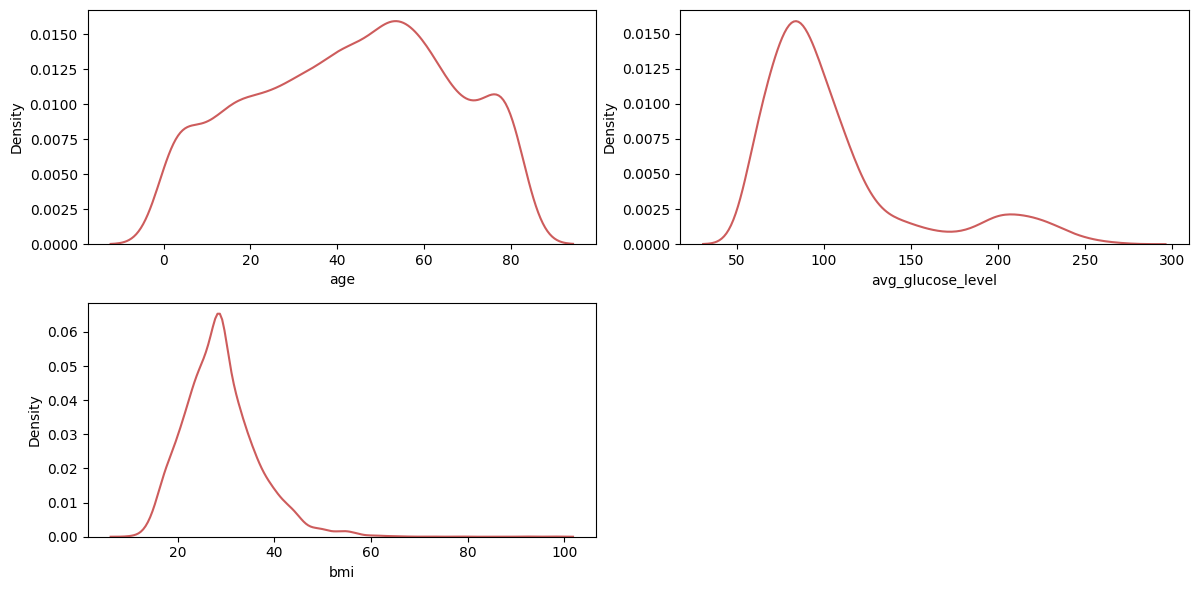

In [145]:
# distribution of data before scaling
plt.figure(figsize=(12, 6))
for i, col in enumerate(continuous_features):
    plt.subplot(2, 2, i+1)
    sns.kdeplot(x=df1[col], color='indianred')
    plt.xlabel(col)
    plt.tight_layout()

- **Here `avg_glucose_level` is slightly skewed**
- **`age` column have kutosis and it is platykurtic**
- **`bmi` is normally distributed with very little data on the tails**

# 6) Label Encoding
* assigning numeric values for the parametres which contains objects coz thats how model will recognize the inputs

In [148]:
data.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1


In [149]:
pip install scipy

Could not fetch URL https://pypi.org/simple/pip/: There was a problem confirming the ssl certificate: HTTPSConnectionPool(host='pypi.org', port=443): Max retries exceeded with url: /simple/pip/ (Caused by SSLError("Can't connect to HTTPS URL because the SSL module is not available.")) - skipping
Note: you may need to restart the kernel to use updated packages.


In [150]:
from sklearn.preprocessing import LabelEncoder
enc=LabelEncoder()
#now we just assigning numeric numbers to each of these object porameters

In [151]:
gender=enc.fit_transform(data['gender'])

In [152]:
smoking_status=enc.fit_transform(data['smoking_status'])

In [153]:
work_type=enc.fit_transform(data['work_type'])
Residence_type=enc.fit_transform(data['Residence_type'])
ever_married=enc.fit_transform(data['ever_married'])

In [154]:
data['work_type']=work_type
#this replaces this work_type(object) to the work_type(number)

In [155]:
data['ever_married']=ever_married
data['Residence_type']=Residence_type
data['smoking_status']=smoking_status
data['gender']=gender

In [156]:
data

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.600000,1,1
1,0,61.0,0,0,1,3,0,202.21,28.893237,2,1
2,1,80.0,0,1,1,2,0,105.92,32.500000,2,1
3,0,49.0,0,0,1,2,1,171.23,34.400000,3,1
4,0,79.0,1,0,1,3,0,174.12,24.000000,2,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,0,80.0,1,0,1,2,1,83.75,28.893237,2,0
5106,0,81.0,0,0,1,3,1,125.20,40.000000,2,0
5107,0,35.0,0,0,1,3,0,82.99,30.600000,2,0
5108,1,51.0,0,0,1,2,0,166.29,25.600000,1,0


In [157]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   int32  
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   int32  
 5   work_type          5110 non-null   int32  
 6   Residence_type     5110 non-null   int32  
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                5110 non-null   float64
 9   smoking_status     5110 non-null   int32  
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int32(5), int64(3)
memory usage: 339.5 KB


#now everything is in numbers or float

# 7) Partitioning 
**Splitting the data for train and test**
- x means the fetaures and Y means the target variable
- 80% of data would be used for training and the 20% would be used for testing

X ---train_X,test_X  80/20                   
Y ---train_Y,test_Y

In [161]:
X=data.drop('stroke',axis=1)
#axis=1 means to the column
#drop means just droping stroke data

In [162]:
X.head()
#without stroke data
#we have 10 features 

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,1,67.0,0,1,1,2,1,228.69,36.600000,1
1,0,61.0,0,0,1,3,0,202.21,28.893237,2
2,1,80.0,0,1,1,2,0,105.92,32.500000,2
3,0,49.0,0,0,1,2,1,171.23,34.400000,3
4,0,79.0,1,0,1,3,0,174.12,24.000000,2


In [163]:
Y=data['stroke']

In [164]:
Y
#this is the stroke data

0       1
1       1
2       1
3       1
4       1
       ..
5105    0
5106    0
5107    0
5108    0
5109    0
Name: stroke, Length: 5110, dtype: int64

In [165]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test=train_test_split(X,Y,test_size=0.2,random_state=10)
#test_size means how much test size i neeed we have given 20% so '0.2'
#random state means randomely distributing data

In [166]:
X_train
#4088 for Xtrain

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
2285,1,49.0,0,0,1,2,0,79.64,28.893237,3
4733,1,67.0,0,0,1,2,0,83.16,25.500000,1
3905,1,78.0,0,0,1,2,1,208.85,24.400000,1
4700,1,47.0,0,0,1,2,0,110.14,30.500000,3
4939,0,59.0,0,0,1,2,1,71.08,28.100000,2
...,...,...,...,...,...,...,...,...,...,...
1180,0,62.0,0,0,1,2,0,82.57,36.000000,1
3441,0,59.0,0,0,1,3,1,90.06,28.900000,3
1344,1,47.0,0,0,1,2,0,86.37,39.200000,3
4623,1,25.0,0,0,1,0,1,166.38,23.100000,2


In [167]:
Y_train

2285    0
4733    0
3905    0
4700    0
4939    0
       ..
1180    0
3441    0
1344    0
4623    0
1289    0
Name: stroke, Length: 4088, dtype: int64

# Testing

In [169]:
X_test

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
2413,0,58.00,0,0,1,2,0,100.42,39.500000,3
1141,1,57.00,0,0,1,2,0,90.06,29.800000,0
146,1,65.00,0,0,1,3,1,68.43,28.893237,1
3883,0,1.64,0,0,0,4,1,69.89,18.100000,0
1044,0,79.00,0,0,1,0,1,93.89,30.400000,2
...,...,...,...,...,...,...,...,...,...,...
2261,1,59.00,0,0,1,2,1,60.35,25.900000,1
4712,1,57.00,0,0,1,2,1,93.04,29.200000,2
4971,0,63.00,0,0,1,2,1,57.06,37.900000,2
2224,1,57.00,0,0,1,2,0,76.28,31.400000,1


In [170]:
Y_test

2413    0
1141    0
146     1
3883    0
1044    0
       ..
2261    0
4712    0
4971    0
2224    0
4825    0
Name: stroke, Length: 1022, dtype: int64

# 8) Normalize

In [172]:
data.describe()
#in this the std is different the mean values are different
#we need to scale down the data
#the mean between age and hypertension we see the distance is too large coz the model will not be able to travel that much distance so we will scale down the mean
#the mean will be zero an dstd will be 1 so the data will be in a range

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000
mean,0.414286,43.226614,0.097456,0.054012,0.656164,2.167710,0.508023,106.147677,28.893237,1.376908,0.048728
std,0.493044,22.612647,0.296607,0.226063,0.475034,1.090293,0.499985,45.283560,7.698018,1.071534,0.215320
min,0.000000,0.080000,0.000000,0.000000,0.000000,0.000000,0.000000,55.120000,10.300000,0.000000,0.000000
25%,0.000000,25.000000,0.000000,0.000000,0.000000,2.000000,0.000000,77.245000,23.800000,0.000000,0.000000
50%,0.000000,45.000000,0.000000,0.000000,1.000000,2.000000,1.000000,91.885000,28.400000,2.000000,0.000000
75%,1.000000,61.000000,0.000000,0.000000,1.000000,3.000000,1.000000,114.090000,32.800000,2.000000,0.000000
max,2.000000,82.000000,1.000000,1.000000,1.000000,4.000000,1.000000,271.740000,97.600000,3.000000,1.000000


In [173]:
from sklearn.preprocessing import StandardScaler
std=StandardScaler()
#storing all the standard scalar in std

In [174]:
X_train_std=std.fit_transform(X_train)
X_test_std=std.transform(X_test)
#we dont need to do this for Y test, train coz it is already in 0 and 1 we just need to do it for x
#we will use 'fit' in X_train and not in X_test coz there is something as data leakage
#coz our model need to know the train data it should not know the testing data
#fit function understands the data which means understand and transform the data
#transform function only tranforms the data

# Save the scaler object

In [176]:
import pickle
import os


In [177]:
scaler_path=os.path.join('C:/Users/Sneha/Documents/A/MSC 5th sem project/heart-stroke-prediction/heart-stroke-classifier\heart-stroke-classifier/Stroke-Risk-Prediction-using-Machine-Learning/models/scaler.pkl')
with open(scaler_path,'wb') as scaler_file:
    pickle.dump(std,scaler_file)

#i stor ex-train and x-test seperately to not create a mess

In [179]:
X_train_std

array([[ 1.19359699,  0.2521852 , -0.33069968, ..., -0.58626884,
         0.00238781,  1.51158251],
       [ 1.19359699,  1.04686385, -0.33069968, ..., -0.50843521,
        -0.44065504, -0.35191245],
       [ 1.19359699,  1.5325008 , -0.33069968, ...,  2.27080023,
        -0.58427812, -0.35191245],
       ...,
       [ 1.19359699,  0.16388757, -0.33069968, ..., -0.43745625,
         1.34810513,  1.51158251],
       [ 1.19359699, -0.80738634, -0.33069968, ...,  1.33171097,
        -0.75401449,  0.57983503],
       [-0.83780372,  1.62079843, -0.33069968, ..., -0.74171498,
        -0.16646553,  0.57983503]])

In [180]:
X_test_std

array([[-0.83780372,  0.64952452, -0.33069968, ..., -0.12678509,
         1.38727506,  1.51158251],
       [ 1.19359699,  0.60537571, -0.33069968, ..., -0.35586361,
         0.12078063, -1.28365994],
       [ 1.19359699,  0.95856622, -0.33069968, ..., -0.83414241,
         0.00238781, -0.35191245],
       ...,
       [-0.83780372,  0.87026859, -0.33069968, ..., -1.08555387,
         1.17836876,  0.57983503],
       [ 1.19359699,  0.60537571, -0.33069968, ..., -0.66056457,
         0.32968693, -0.35191245],
       [-0.83780372, -1.29302329, -0.33069968, ..., -0.75962556,
        -1.31545016, -1.28365994]])

# 9) Training ML Models

# 9.1 Decision Tree

In [183]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
#we will store all the decisiontreeclasifier in the dt variable

In [184]:
dt.fit(X_train_std,Y_train)

DecisionTreeClassifier()

In [185]:
dt.feature_importances_
#according to dt these are the features that are the most important
#bmi age and glucose level are the most important features acc to dt 

array([0.03135168, 0.17447025, 0.01469891, 0.03068245, 0.0318653 ,
       0.05303095, 0.04468139, 0.30085587, 0.25044863, 0.06791456])

In [186]:
X_train.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status'],
      dtype='object')

In [187]:
Y_pred=dt.predict(X_test_std)

In [188]:
Y_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [189]:
from sklearn.metrics import accuracy_score

In [190]:
ac_dt=accuracy_score(Y_test,Y_pred)

# Accuracy score of Decision tree

In [192]:
ac_dt

0.9041095890410958

In [193]:
import joblib
model_path=os.path.join('C:/Users/Sneha/Documents/A/MSC 5th sem project/heart-stroke-prediction/heart-stroke-classifier/heart-stroke-classifier/Stroke-Risk-Prediction-using-Machine-Learning/models/dt.sav')
joblib.dump(dt,model_path)

['C:/Users/Sneha/Documents/A/MSC 5th sem project/heart-stroke-prediction/heart-stroke-classifier/heart-stroke-classifier/Stroke-Risk-Prediction-using-Machine-Learning/models/dt.sav']

# 9.2 Logistic Regression

In [195]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()

In [196]:
lr.fit(X_train_std,Y_train)

LogisticRegression()

In [197]:
Y_pred_lr=lr.predict(X_test_std)

In [198]:
Y_pred_lr

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [199]:
ac_lr=accuracy_score(Y_test,Y_pred_lr)

# Accuracy score of Logistic regression

In [201]:
ac_lr

0.9383561643835616

In [202]:
import joblib
model_path=os.path.join('C:/Users/Sneha/Documents/A/MSC 5th sem project/heart-stroke-prediction/heart-stroke-classifier/heart-stroke-classifier/Stroke-Risk-Prediction-using-Machine-Learning/models/lr.sav')
joblib.dump(lr,model_path)

['C:/Users/Sneha/Documents/A/MSC 5th sem project/heart-stroke-prediction/heart-stroke-classifier/heart-stroke-classifier/Stroke-Risk-Prediction-using-Machine-Learning/models/lr.sav']

# 9.3 KNN

In [204]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()

In [205]:
knn.fit(X_train_std,Y_train)

KNeighborsClassifier()

In [206]:
Y_pred=knn.predict(X_test_std)

In [207]:
ac_knn=accuracy_score(Y_test,Y_pred)

accuracy score of KNN classifier

In [209]:
ac_knn

0.9344422700587084

In [210]:
import joblib
model_path=os.path.join('C:/Users/Sneha/Documents/A/MSC 5th sem project/heart-stroke-prediction/heart-stroke-classifier/heart-stroke-classifier/Stroke-Risk-Prediction-using-Machine-Learning/models/knn.sav')
joblib.dump(knn,model_path)

['C:/Users/Sneha/Documents/A/MSC 5th sem project/heart-stroke-prediction/heart-stroke-classifier/heart-stroke-classifier/Stroke-Risk-Prediction-using-Machine-Learning/models/knn.sav']

# 9.4 Random Forest
#its an updated version of decision tree it has bunch of trees
#if out of three tress two trees shows the same answer then it follows the majority rule
#it solves the problem of over and fitting

In [212]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()

In [213]:
rf.fit(X_train_std,Y_train)

RandomForestClassifier()

In [214]:
Y_pred=rf.predict(X_test_std)

In [215]:
ac_rf=accuracy_score(Y_test,Y_pred)

# Accuracy score of Random forest

In [217]:
ac_rf

0.9373776908023483

In [218]:
import joblib
model_path=os.path.join('C:/Users/Sneha/Documents/A/MSC 5th sem project/heart-stroke-prediction/heart-stroke-classifier/heart-stroke-classifier/Stroke-Risk-Prediction-using-Machine-Learning/models/rf.sav')
joblib.dump(rf,model_path)

['C:/Users/Sneha/Documents/A/MSC 5th sem project/heart-stroke-prediction/heart-stroke-classifier/heart-stroke-classifier/Stroke-Risk-Prediction-using-Machine-Learning/models/rf.sav']

# 9.5 SVM
#is also about classification

In [220]:
from sklearn.svm import SVC
#svc is supportvector classifier
#svr is supportvector regression

In [221]:
sv=SVC()

In [222]:
sv.fit(X_train_std,Y_train)

SVC()

In [223]:
Y_pred=sv.predict(X_test_std)

In [224]:
ac_sv=accuracy_score(Y_test,Y_pred)

# Accuracy score of SVM

In [226]:
ac_sv

0.9393346379647749

In [227]:
import joblib
model_path=os.path.join('C:/Users/Sneha/Documents/A/MSC 5th sem project/heart-stroke-prediction/heart-stroke-classifier/heart-stroke-classifier/Stroke-Risk-Prediction-using-Machine-Learning/models/sv.sav')
joblib.dump(sv,model_path)

['C:/Users/Sneha/Documents/A/MSC 5th sem project/heart-stroke-prediction/heart-stroke-classifier/heart-stroke-classifier/Stroke-Risk-Prediction-using-Machine-Learning/models/sv.sav']

In [228]:
ac_lr

0.9383561643835616

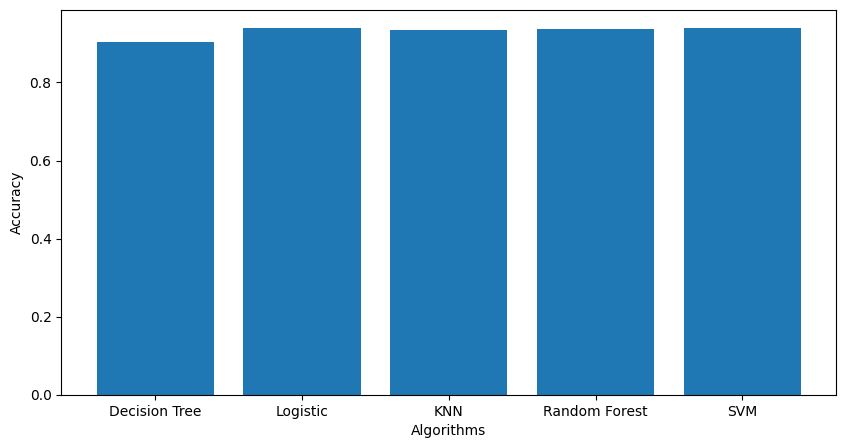

In [229]:
plt.bar(['Decision Tree','Logistic','KNN','Random Forest','SVM'],[ac_dt,ac_lr,ac_knn,ac_rf,ac_sv])
plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.show()

In [230]:
from sklearn.metrics import accuracy_score, classification_report

best_model = RandomForestClassifier()
best_model = best_model.fit(X_train_std, Y_train)

# Predict on test data
Y_pred = best_model.predict(X_test_std)

# Calculate accuracy score
score = accuracy_score(Y_test, Y_pred) 

cr = classification_report(Y_test, Y_pred)

print("FINAL MODEL 'Random Forest Classifier")
print("Accuracy Score value: {:.4f}".format(score))
print(cr)

FINAL MODEL 'Random Forest Classifier
Accuracy Score value: 0.9384
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022

